# IBM Sales Opportunity Win/Loss — Dataset-First Baseline

## 1. Project setup
Estimate historical WON probability, not marketing impact. Run the notebook from top to bottom using one Python kernel with NumPy, pandas, matplotlib and scikit-learn installed. XGBoost is optional; no automatic downloads occur during analysis.

The CSV is loaded from the repository, without uploads or machine-specific paths. In Colab, clone/mount the **whole repository** and change into it first. Package versions and a data fingerprint make this run traceable.

In [1]:
# 1. Repository-relative loading; no upload or network access is required.
from pathlib import Path
import hashlib
import platform
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

SEED = 42
pd.set_option("display.max_columns", 24)
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_colwidth", 100)

relative_csv = Path("datasets") / "IBM-sales-opportunity.csv"
# Works from the repository root or any directory nested inside it.
candidates = [parent / relative_csv for parent in (Path.cwd(), *Path.cwd().parents)]
data_path = next((path for path in candidates if path.is_file()), None)
if data_path is None:
    raise FileNotFoundError(
        f"Cannot find {relative_csv}. Open/run this notebook inside the cloned repository. "
        "In Colab, clone or mount the whole repository and change into its directory first; "
        "opening only the notebook from GitHub does not copy the CSV."
    )
# 'None' is a real Competitor Type, not a null. Only blank CSV fields are missing.
df = pd.read_csv(data_path, keep_default_na=False, na_values=[""])
ID, TARGET = "Opportunity Number", "Opportunity Result"
assert df[ID].notna().all()
assert set(df[TARGET].unique()) == {"Won", "Loss"}, "Unexpected target labels"
print(f"Dataset: {relative_csv}; dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("CSV SHA-256:", hashlib.sha256(data_path.read_bytes()).hexdigest())
print("Python:", platform.python_version())
for package in ["numpy", "pandas", "scikit-learn", "matplotlib"]:
    print(f"{package}: {version(package)}")
display(df.head(3))

Dataset: datasets/IBM-sales-opportunity.csv; dimensions: 78,025 rows × 19 columns
CSV SHA-256: 31afdb83aa46b54f62f5cdbfe1ccf00f395266254a0249c96ceef8522cc12b24
Python: 3.12.3
numpy: 2.5.3
pandas: 3.0.6
scikit-learn: 1.9.1
matplotlib: 3.11.2


,Opportunity Number,Supplies Subgroup,Supplies Group,Region,Route To Market,Elapsed Days In Sales Stage,Opportunity Result,Sales Stage Change Count,Total Days Identified Through Closing,Total Days Identified Through Qualified,Opportunity Amount USD,Client Size By Revenue,Client Size By Employee Count,Revenue From Client Past Two Years,Competitor Type,Ratio Days Identified To Total Days,Ratio Days Validated To Total Days,Ratio Days Qualified To Total Days,Deal Size Category
0,1641984,Exterior Accessories,Car Accessories,Northwest,Fields Sales,76,Won,13,104,101,0,5,5,0,Unknown,0.69636,0.113985,0.154215,1
1,1658010,Exterior Accessories,Car Accessories,Pacific,Reseller,63,Loss,2,163,163,0,3,5,0,Unknown,0.00000,1.000000,0.000000,1
2,1674737,Motorcycle Parts,Performance & Non-auto,Pacific,Reseller,24,Won,7,82,82,7750,1,1,0,Unknown,1.00000,0.000000,0.000000,1


## 2. Dataset structure and quality
Inspect every column, missing values, representative values and the actual target labels. Preserve the legitimate competitor category `None`; it must not be interpreted as a missing value.

In [2]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(),
    "representative values (most frequent)": [
        ", ".join(map(str, df[c].value_counts().head(5).index)) for c in df
    ],
})
display(audit)
target_distribution = df[TARGET].value_counts().rename("rows").to_frame()
target_distribution["percent"] = 100 * target_distribution["rows"] / len(df)
display(target_distribution.round(2))
print(f"Exact duplicate rows: {df.duplicated().sum():,}")
print(f"Unique opportunity IDs: {df[ID].nunique():,}")
display(df.select_dtypes(include="number").agg(["min", "median", "max"]).T)
print("Categorical domains:")
for column in df.select_dtypes(exclude="number"):
    print(f"{column}: {sorted(df[column].dropna().unique())}")

,dtype,missing,unique,representative values (most frequent)
Opportunity Number,int64,0,77829,"7281765, 8093335, 9782603, 6704540, 6835459"
Supplies Subgroup,str,0,11,"Motorcycle Parts, Exterior Accessories, Garage & Car Care, Shelters & RV, Batteries & Accessories"
Supplies Group,str,0,4,"Car Accessories, Performance & Non-auto, Tires & Wheels, Car Electronics"
Region,str,0,7,"Midwest, Pacific, Northwest, Southeast, Southwest"
Route To Market,str,0,5,"Fields Sales, Reseller, Other, Telesales, Telecoverage"
Elapsed Days In Sales Stage,int64,0,138,"16, 44, 62, 7, 23"
Opportunity Result,str,0,2,"Loss, Won"
Sales Stage Change Count,int64,0,22,"2, 3, 4, 5, 1"
Total Days Identified Through Closing,int64,0,156,"0, 1, 2, 3, 4"
Total Days Identified Through Qualified,int64,0,156,"0, 1, 2, 3, 4"


,rows,percent
Opportunity Result,,
Loss,60398,77.41
Won,17627,22.59


Exact duplicate rows: 55
Unique opportunity IDs: 77,829


,min,median,max
Opportunity Number,1641984.0,7545569.000,10094266.0
Elapsed Days In Sales Stage,0.0,43.000,210.0
Sales Stage Change Count,1.0,3.000,23.0
Total Days Identified Through Closing,0.0,12.000,208.0
Total Days Identified Through Qualified,0.0,12.000,208.0
Opportunity Amount USD,0.0,49000.000,1000000.0
Client Size By Revenue,1.0,1.000,5.0
Client Size By Employee Count,1.0,1.000,5.0
Revenue From Client Past Two Years,0.0,0.000,4.0
Ratio Days Identified To Total Days,0.0,0.000,1.0


Categorical domains:
Supplies Subgroup: ['Batteries & Accessories', 'Car Electronics', 'Exterior Accessories', 'Garage & Car Care', 'Interior Accessories', 'Motorcycle Parts', 'Performance Parts', 'Replacement Parts', 'Shelters & RV', 'Tires & Wheels', 'Towing & Hitches']
Supplies Group: ['Car Accessories', 'Car Electronics', 'Performance & Non-auto', 'Tires & Wheels']
Region: ['Mid-Atlantic', 'Midwest', 'Northeast', 'Northwest', 'Pacific', 'Southeast', 'Southwest']
Route To Market: ['Fields Sales', 'Other', 'Reseller', 'Telecoverage', 'Telesales']
Opportunity Result: ['Loss', 'Won']
Competitor Type: ['Known', 'None', 'Unknown']


## 3. Opportunity identity, redundancy and timing
Distinguish exact copies from nonidentical records sharing an opportunity number. Product differences alone suggest line items, but cannot prove that interpretation. Inspect conflicting outcomes and other changing fields before choosing the unit of prediction. Duration fields are not calendar dates.

In [3]:
counts = df[ID].value_counts()
deduplicated = df.drop_duplicates().copy()
distinct_counts = deduplicated[ID].value_counts()
ambiguous_ids = distinct_counts[distinct_counts > 1].index
repeated = deduplicated[deduplicated[ID].isin(ambiguous_ids)]
variation = repeated.groupby(ID).nunique(dropna=False)
print("Raw repeated IDs:", int((counts > 1).sum()),
      "| Rows in those IDs:", int(counts[counts > 1].sum()))
print("Nonidentical repeated IDs after deduplication:", len(ambiguous_ids),
      "| Rows:", len(repeated))
print("Conflicting outcomes:", int((variation[TARGET] > 1).sum()))
display((variation > 1).sum().rename("IDs with varying values").to_frame())
display(repeated[repeated[ID].isin(ambiguous_ids[:3])].sort_values(ID))

subgroup_mapping = df.groupby("Supplies Subgroup")["Supplies Group"].nunique()
print("Subgroup uniquely determines group:", bool(subgroup_mapping.eq(1).all()))
display(df.groupby("Deal Size Category")["Opportunity Amount USD"].agg(["count", "min", "max"]))
print("Amounts mapping to multiple deal-size categories:", int((
    df.groupby("Opportunity Amount USD")["Deal Size Category"].nunique() > 1
).sum()))
print("Zero amounts:", int(df["Opportunity Amount USD"].eq(0).sum()))
print("No creation/closing/snapshot date or customer ID exists in the 19-column schema.")
print("Elapsed/total days cannot support a chronological split; opportunity ID is not a date.")

Raw repeated IDs: 183 | Rows in those IDs: 379
Nonidentical repeated IDs after deduplication: 137 | Rows: 278
Conflicting outcomes: 0


,IDs with varying values
Supplies Subgroup,46
Supplies Group,20
Region,0
Route To Market,0
Elapsed Days In Sales Stage,0
Opportunity Result,0
Sales Stage Change Count,0
Total Days Identified Through Closing,0
Total Days Identified Through Qualified,0
Opportunity Amount USD,135


,Opportunity Number,Supplies Subgroup,Supplies Group,Region,Route To Market,Elapsed Days In Sales Stage,Opportunity Result,Sales Stage Change Count,Total Days Identified Through Closing,Total Days Identified Through Qualified,Opportunity Amount USD,Client Size By Revenue,Client Size By Employee Count,Revenue From Client Past Two Years,Competitor Type,Ratio Days Identified To Total Days,Ratio Days Validated To Total Days,Ratio Days Qualified To Total Days,Deal Size Category
45759,4787647,Batteries & Accessories,Car Accessories,Southeast,Fields Sales,26,Won,6,49,46,0,1,4,0,Unknown,0.431174,0.293522,0.210526,1
45760,4787647,Shelters & RV,Performance & Non-auto,Southeast,Fields Sales,26,Won,6,49,46,0,1,4,0,Unknown,0.431174,0.293522,0.210526,1
45761,4787647,Interior Accessories,Car Accessories,Southeast,Fields Sales,26,Won,6,49,46,6000,1,4,0,Unknown,0.431174,0.293522,0.210526,1
10488,6835459,Replacement Parts,Car Accessories,Pacific,Fields Sales,90,Won,1,0,0,56073,1,1,0,Unknown,0.000000,0.000000,0.000000,4
10490,6835459,Replacement Parts,Car Accessories,Pacific,Fields Sales,90,Won,1,0,0,9281,1,1,0,Unknown,0.000000,0.000000,0.000000,1
10489,6835459,Replacement Parts,Car Accessories,Pacific,Fields Sales,90,Won,1,0,0,41964,1,1,0,Unknown,0.000000,0.000000,0.000000,3
18755,7281765,Batteries & Accessories,Car Accessories,Pacific,Reseller,66,Won,4,8,5,45000,5,1,0,Known,0.000000,0.320000,0.333333,3
18753,7281765,Batteries & Accessories,Car Accessories,Pacific,Reseller,66,Won,4,8,5,15000,5,1,0,Known,0.000000,0.320000,0.333333,2
18754,7281765,Batteries & Accessories,Car Accessories,Pacific,Reseller,66,Won,4,8,5,60000,5,1,0,Known,0.000000,0.320000,0.333333,4


Subgroup uniquely determines group: True


,count,min,max
Deal Size Category,,,
1,12095,0,9999
2,15123,10000,24999
3,11968,25000,49999
4,13628,50000,99999
5,18074,100000,249999
6,4934,250000,499999
7,2203,500000,1000000


Amounts mapping to multiple deal-size categories: 0
Zero amounts: 2047
No creation/closing/snapshot date or customer ID exists in the 19-column schema.
Elapsed/total days cannot support a chronological split; opportunity ID is not a date.


## 4. Prediction point and feature policy
**Scoring point:** initial opportunity registration, after the proposed product, territory and initial sales route have been recorded, but before qualification/progression. Estimate eventual `Won` among comparable historical resolved opportunities. The CSV has no snapshots: even these initial values cannot be verified retrospectively.

### SAFE PRE-PREDICTION FEATURES
- **Supplies Subgroup, Region, Route To Market:** plausible registration inputs under the definition above. Route means the existing sales route, not an optimal contact channel. These three form the conservative primary model.

### QUESTIONABLE / REQUIRES BUSINESS ASSUMPTION
- **Opportunity Amount USD / Log Opportunity Amount:** initial estimate could exist, but this export may contain a revised/final amount. Zero may mean unknown; log transformation does not remove leakage.
- **Client Size By Revenue / Employee Count:** usable only if profiles/bands existed at scoring time. Codes 1–5 have no supplied band definitions; encode as categories, not measured revenue or headcount.
- **Revenue From Client Past Two Years:** codes 0–4, not dollar amounts. Requires a lookback ending before scoring. Zero is not proven to mean a new customer; existing customers can have no recent purchases. No customer ID/new-customer flag validates cold-start performance.
- **Competitor Type:** often discovered during qualification, not creation. `Unknown`, `Known` and `None` are distinct; later updates could encode progression. Excluded from the primary model regardless of accuracy.

### EXCLUDE / LEAKAGE / IDENTIFIER
- **Opportunity Number:** grouping/audit identifier; **Opportunity Result:** target only.
- **Supplies Group:** exactly determined by subgroup. **Deal Size Category:** deterministic amount bands; redundant and inherits amount-timing risk.
- **Elapsed Days In Sales Stage, Sales Stage Change Count, Total Days Identified Through Closing/Qualified, all three Ratio Days fields:** progression/future-duration information, unavailable at the chosen scoring point. Duration ratios can indirectly encode outcome/progression; exclude rather than justify by predictive power.

After 55 exact copies are removed, 137 IDs retain nonidentical rows (278 rows). Differences are consistent with line items, not demonstrated snapshots; there is no item/date key. Exclude these ambiguous IDs for a **single-record-opportunity** baseline, report the selection effect, and do not generalize to multi-item opportunities.

In [4]:
model_df = deduplicated.loc[~deduplicated[ID].isin(ambiguous_ids)].copy()
model_df["target"] = model_df[TARGET].map({"Won": 1, "Loss": 0}).astype(int)
assert model_df[ID].is_unique
assert model_df["Opportunity Amount USD"].ge(0).all()
features = ["Supplies Subgroup", "Region", "Route To Market"]
profile_features = ["Client Size By Revenue", "Client Size By Employee Count"]
history_feature = "Revenue From Client Past Two Years"
amount_feature = "Opportunity Amount USD"
print("Primary features:", features)
print(f"Retained {len(model_df):,} single-record opportunities; excluded {len(ambiguous_ids):,} ambiguous IDs")
selection_audit = pd.DataFrame({
    "opportunities": [df[ID].nunique(), len(ambiguous_ids), len(model_df)],
    "WON rate": [df.drop_duplicates(ID)[TARGET].eq("Won").mean(),
                 repeated.drop_duplicates(ID)[TARGET].eq("Won").mean(),
                 model_df["target"].mean()],
}, index=["All unique IDs", "Excluded nonidentical IDs", "Retained IDs"])
display(selection_audit.round(4))
display(model_df[TARGET].value_counts().rename("retained opportunities").to_frame())

Primary features: ['Supplies Subgroup', 'Region', 'Route To Market']
Retained 77,692 single-record opportunities; excluded 137 ambiguous IDs


,opportunities,WON rate
All unique IDs,77829,0.2255
Excluded nonidentical IDs,137,0.3504
Retained IDs,77692,0.2252


,retained opportunities
Opportunity Result,
Loss,60192
Won,17500


## 5. Leakage-aware evaluation split
Use separate **training (~50%), calibration (~10%), validation (~20%) and final test (~20%)** partitions. All splits are grouped by opportunity ID and approximately stratified. Even though ambiguous IDs were excluded, explicit overlap assertions protect future revisions.

There are no calendar dates, so chronological validation is impossible. Customer-level overlap also cannot be checked without a customer ID. Preprocessing is fitted only on training data; calibration is fitted separately, and validation chooses the model/probability variant and classification threshold. The final test is not used for those choices.

In [5]:
from itertools import combinations
from sklearn.model_selection import StratifiedGroupKFold

def grouped_holdout(frame, folds, seed):
    splitter = StratifiedGroupKFold(n_splits=folds, shuffle=True, random_state=seed)
    keep, holdout = next(splitter.split(frame[features], frame["target"], groups=frame[ID]))
    return frame.iloc[keep].copy(), frame.iloc[holdout].copy()

development_df, test_df = grouped_holdout(model_df, 5, SEED)
fit_df, validation_df = grouped_holdout(development_df, 4, SEED + 1)
train_df, calibration_df = grouped_holdout(fit_df, 6, SEED + 2)
partitions = {"train": train_df, "calibration": calibration_df,
              "validation": validation_df, "test": test_df}
for (name_a, a), (name_b, b) in combinations(partitions.items(), 2):
    assert set(a[ID]).isdisjoint(b[ID]), f"ID overlap: {name_a}/{name_b}"
assert sum(map(len, partitions.values())) == len(model_df)
display(pd.DataFrame([
    {"partition": name, "opportunities": len(frame), "WON rate": frame["target"].mean()}
    for name, frame in partitions.items()
 ]).set_index("partition").round(4))
print("All six pairwise opportunity-ID overlap checks passed.")
for name, frame in partitions.items():
    for column in features + profile_features + [history_feature, "Competitor Type"]:
        unseen = set(frame[column].dropna()) - set(train_df[column].dropna())
        assert not unseen, f"Unseen {column} in {name}: {unseen}"
print("All evaluated categorical values occur in training data.")
X_train, y_train = train_df[features], train_df["target"]
X_validation, y_validation = validation_df[features], validation_df["target"]
X_test, y_test = test_df[features], test_df["target"]

,opportunities,WON rate
partition,,
train,38846,0.2252
calibration,7769,0.2253
validation,15538,0.2253
test,15539,0.2252


All six pairwise opportunity-ID overlap checks passed.
All evaluated categorical values occur in training data.


## 6. Baseline models and preprocessing
Compare a prevalence-only baseline, Logistic Regression and a regularized Random Forest. Include XGBoost only if already installed; otherwise state that it was not tested. Categorical encoding rejects unknown categories instead of silently assigning all-zero vectors. Numeric sensitivity features use median imputation, log amount and scaling inside the pipeline.

Keep the natural ~22.5% WON prevalence: no SMOTE or automatic class weighting, which can distort probability estimates. Use PR-AUC (average precision), ROC-AUC, Brier score and log loss; report classification metrics at 0.5 here. Hyperparameters are fixed, not tuned against test results.

In [6]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
    recall_score, f1_score, brier_score_loss, log_loss, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay)

def make_pipeline(estimator, categorical, numeric=None):
    numeric = numeric or []
    transformers = [("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="error", sparse_output=False)),
    ]), categorical)]
    if numeric:
        transformers.append(("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
            ("scale", StandardScaler()),
        ]), numeric))
    return Pipeline([("preprocess", ColumnTransformer(transformers)),
                     ("model", clone(estimator))])

def metrics(y, probability, threshold=0.5):
    prediction = np.asarray(probability) >= threshold
    return {"ROC-AUC": roc_auc_score(y, probability),
            "PR-AUC (AP)": average_precision_score(y, probability),
            "precision": precision_score(y, prediction, zero_division=0),
            "recall": recall_score(y, prediction, zero_division=0),
            "F1": f1_score(y, prediction, zero_division=0),
            "Brier": brier_score_loss(y, probability),
            "log loss": log_loss(y, probability)}

estimators = {
    "Prevalence baseline": DummyClassifier(strategy="prior"),
    "Logistic Regression": LogisticRegression(max_iter=1500, C=1.0, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12,
        min_samples_leaf=30, max_features=0.8, n_jobs=2, random_state=SEED),
}
try:
    from xgboost import XGBClassifier
except ImportError:
    print("XGBoost not installed: comparison skipped; no download needed to run this notebook.")
else:
    estimators["XGBoost"] = XGBClassifier(n_estimators=250, max_depth=3,
        learning_rate=0.05, min_child_weight=10, subsample=0.9, colsample_bytree=0.9,
        reg_lambda=5, objective="binary:logistic", eval_metric="logloss",
        tree_method="hist", n_jobs=2, random_state=SEED)
    print("XGBoost version:", version("xgboost"))

models, validation_rows = {}, []
for name, estimator in estimators.items():
    fitted = make_pipeline(estimator, features).fit(X_train, y_train)
    models[name] = fitted
    p = fitted.predict_proba(X_validation)[:, 1]
    validation_rows.append({"model": name, **metrics(y_validation, p)})
validation_comparison = pd.DataFrame(validation_rows).set_index("model")
display(validation_comparison.round(4))

XGBoost not installed: comparison skipped; no download needed to run this notebook.


,ROC-AUC,PR-AUC (AP),precision,recall,F1,Brier,log loss
model,,,,,,,
Prevalence baseline,0.5000,0.2253,0.0,0.0,0.0,0.1745,0.5335
Logistic Regression,0.6006,0.3021,0.0,0.0,0.0,0.1706,0.5223
Random Forest,0.6125,0.3067,0.0,0.0,0.0,0.1694,0.5191


## 7. Feature assumptions and the old “cold-start” model
Validation-only sensitivity tests add customer bands, amount, history, then competitor status to the same Random Forest. These are **not eligible for the primary model**: better performance cannot establish when a value became known.

Removing history is an availability ablation, not proof of new-customer performance. Removing region does not establish transfer to another industry. The old generic/ERP example was unsupported; this dataset contains automotive/accessory product categories. Supplies Group and Deal Size Category remain excluded as redundant.

In [7]:
sensitivity_sets = {
    "Primary: registration only": (features, []),
    "+ client profile bands": (features + profile_features, []),
    "+ amount, no history (not validated cold-start)": (features + profile_features, [amount_feature]),
    "+ historical revenue band": (features + profile_features + [history_feature], [amount_feature]),
    "+ competitor (timing risk)": (features + profile_features + [history_feature, "Competitor Type"], [amount_feature]),
}
sensitivity_rows = []
for name, (categorical, numeric) in sensitivity_sets.items():
    columns = categorical + numeric
    if name.startswith("Primary"):
        fitted = models["Random Forest"]
    else:
        fitted = make_pipeline(estimators["Random Forest"], categorical, numeric)
        fitted.fit(train_df[columns], y_train)
    p = fitted.predict_proba(validation_df[columns])[:, 1]
    sensitivity_rows.append({"feature assumption": name, "features": len(columns),
                             **metrics(y_validation, p)})
sensitivity_comparison = pd.DataFrame(sensitivity_rows).set_index("feature assumption")
display(sensitivity_comparison.round(4))
print("Training-only checks: associations are not evidence of pre-prediction availability.")
for column in [history_feature, "Competitor Type"]:
    display(train_df.groupby(column)["target"].agg(["count", "mean"]).round(4))
display(train_df.assign(zero_amount=train_df[amount_feature].eq(0))
        .groupby("zero_amount")["target"].agg(["count", "mean"]).round(4))

,features,ROC-AUC,PR-AUC (AP),precision,recall,F1,Brier,log loss
feature assumption,,,,,,,,
Primary: registration only,3,0.6125,0.3067,0.0000,0.0000,0.0000,0.1694,0.5191
+ client profile bands,5,0.6189,0.3171,0.6250,0.0043,0.0085,0.1688,0.5174
"+ amount, no history (not validated cold-start)",6,0.7834,0.4886,0.5844,0.1909,0.2877,0.1435,0.4433
+ historical revenue band,7,0.8206,0.5978,0.6938,0.3171,0.4353,0.1292,0.4080
+ competitor (timing risk),8,0.8195,0.5984,0.6948,0.3174,0.4358,0.1294,0.4086


Training-only checks: associations are not evidence of pre-prediction availability.


,count,mean
Revenue From Client Past Two Years,,
0,34469,0.1739
1,880,0.8125
2,1037,0.7242
3,1043,0.6184
4,1417,0.4552


,count,mean
Competitor Type,,
Known,5935,0.1916
None,4603,0.3122
Unknown,28308,0.2182


,count,mean
zero_amount,,
False,37855,0.2272
True,991,0.1524


## 8. Probability calibration and model selection
Fit a sigmoid mapping of each model’s log-odds using **only the calibration partition**. Compare raw and calibrated probabilities on validation data; select the lowest validation Brier score (log loss breaks ties). Calibration is not automatically an improvement.

Choose a validation F1-maximizing threshold separately for illustration. It is not a business-optimal threshold: no contact cost, intervention benefit or capacity constraint is supplied. Probability estimates are independent of this classification cutoff.

In [8]:
from sklearn.metrics import precision_recall_curve

def log_odds(probability):
    p = np.clip(np.asarray(probability, dtype=float), 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p)).reshape(-1, 1)

candidates, calibration_rows = {}, []
for name, fitted in models.items():
    raw_val = fitted.predict_proba(X_validation)[:, 1]
    candidates[name + " | raw"] = (fitted, None)
    calibration_rows.append({"candidate": name + " | raw", **metrics(y_validation, raw_val)})
    if name == "Prevalence baseline":
        continue
    raw_cal = fitted.predict_proba(calibration_df[features])[:, 1]
    calibrator = LogisticRegression(C=1e6, solver="lbfgs", max_iter=1000)
    calibrator.fit(log_odds(raw_cal), calibration_df["target"])
    cal_val = calibrator.predict_proba(log_odds(raw_val))[:, 1]
    candidates[name + " | sigmoid"] = (fitted, calibrator)
    calibration_rows.append({"candidate": name + " | sigmoid", **metrics(y_validation, cal_val)})

calibration_comparison = pd.DataFrame(calibration_rows).set_index("candidate")
calibration_comparison = calibration_comparison.sort_values(["Brier", "log loss"])
display(calibration_comparison.round(5))
chosen_name = calibration_comparison.index[0]
final_pipeline, final_calibrator = candidates[chosen_name]

def final_probability(frame):
    raw = final_pipeline.predict_proba(frame[features])[:, 1]
    if final_calibrator is None:
        return raw
    return final_calibrator.predict_proba(log_odds(raw))[:, 1]

validation_probability = final_probability(validation_df)
prec, rec, thresholds = precision_recall_curve(y_validation, validation_probability)
f1_values = 2 * prec[:-1] * rec[:-1] / np.maximum(prec[:-1] + rec[:-1], 1e-12)
chosen_threshold = float(thresholds[np.argmax(f1_values)])
print("Locked primary model:", chosen_name)
print(f"Validation-selected F1 threshold: {chosen_threshold:.4f}")
print("The final test has not been used for training, calibration, model selection or threshold selection.")

,ROC-AUC,PR-AUC (AP),precision,recall,F1,Brier,log loss
candidate,,,,,,,
Random Forest | raw,0.61249,0.30672,0.0,0.0,0.0,0.16945,0.51914
Random Forest | sigmoid,0.61249,0.30672,0.0,0.0,0.0,0.16951,0.51934
Logistic Regression | sigmoid,0.60059,0.30212,0.0,0.0,0.0,0.17058,0.52236
Logistic Regression | raw,0.60059,0.30212,0.0,0.0,0.0,0.17060,0.52231
Prevalence baseline | raw,0.50000,0.22525,0.0,0.0,0.0,0.17451,0.53348


Locked primary model: Random Forest | raw
Validation-selected F1 threshold: 0.1844
The final test has not been used for training, calibration, model selection or threshold selection.


## 9. Final held-out evaluation
Evaluate the locked conservative model once on the test opportunities. Report both the conventional 0.5 cutoff and the validation-selected cutoff; compare with the training-prevalence probability baseline. ROC/PR measure ranking, while Brier/log loss measure probability quality.

A well-calibrated model can still rank poorly. Bootstrap intervals below reflect test-sample uncertainty for a fixed fitted model—not training variability, temporal drift or deployment validity.

,ROC-AUC,PR-AUC (AP),precision,recall,F1,Brier,log loss
evaluation,,,,,,,
Prevalence baseline @ 0.5,0.5000,0.2252,0.0000,0.0000,0.0000,0.1745,0.5335
Primary @ 0.5,0.6188,0.3105,0.0000,0.0000,0.0000,0.1689,0.5177
Primary @ 0.1844,0.6188,0.3105,0.2656,0.7523,0.3926,0.1689,0.5177


Brier skill vs prevalence: 3.19%
Test predicted range: 3.3%–42.5%
Confusion matrices: rows actual [Loss, Won], columns predicted [Loss, Won]
At 0.5:
 [[12039     0]
 [ 3500     0]]
At selected threshold:
 [[4760 7279]
 [ 867 2633]]


,95% lower,95% upper
ROC-AUC,0.6078,0.6301
PR-AUC (AP),0.2987,0.3233
Brier,0.1648,0.1726


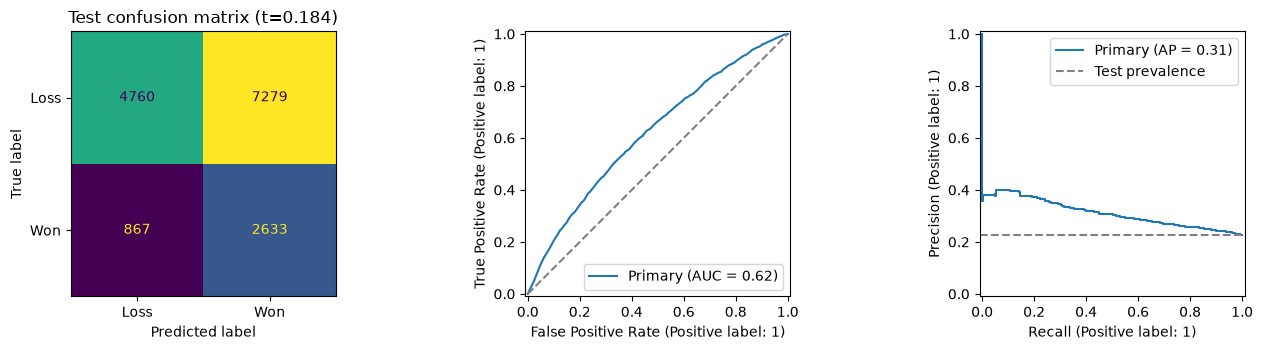

In [9]:
test_probability = final_probability(test_df)
baseline_probability = np.full(len(test_df), y_train.mean())
test_metrics = pd.DataFrame([
    {"evaluation": "Prevalence baseline @ 0.5", **metrics(y_test, baseline_probability)},
    {"evaluation": "Primary @ 0.5", **metrics(y_test, test_probability)},
    {"evaluation": f"Primary @ {chosen_threshold:.4f}",
     **metrics(y_test, test_probability, chosen_threshold)},
 ]).set_index("evaluation")
display(test_metrics.round(4))
final_metrics = metrics(y_test, test_probability, chosen_threshold)
brier_skill = 1 - final_metrics["Brier"] / brier_score_loss(y_test, baseline_probability)
print(f"Brier skill vs prevalence: {brier_skill:.2%}")
print(f"Test predicted range: {test_probability.min():.1%}–{test_probability.max():.1%}")
print("Confusion matrices: rows actual [Loss, Won], columns predicted [Loss, Won]")
print("At 0.5:\n", confusion_matrix(y_test, test_probability >= 0.5, labels=[0, 1]))
print("At selected threshold:\n", confusion_matrix(y_test, test_probability >= chosen_threshold, labels=[0, 1]))

rng = np.random.default_rng(SEED)
y_array = y_test.to_numpy()
bootstrap = []
for _ in range(200):
    indices = rng.integers(0, len(y_array), size=len(y_array))
    y_b, p_b = y_array[indices], test_probability[indices]
    bootstrap.append([roc_auc_score(y_b, p_b), average_precision_score(y_b, p_b),
                      brier_score_loss(y_b, p_b)])
display(pd.DataFrame(np.quantile(bootstrap, [0.025, 0.975], axis=0).T,
    index=["ROC-AUC", "PR-AUC (AP)", "Brier"], columns=["95% lower", "95% upper"]).round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
ConfusionMatrixDisplay.from_predictions(y_test, test_probability >= chosen_threshold,
    display_labels=["Loss", "Won"], ax=axes[0], colorbar=False)
axes[0].set_title(f"Test confusion matrix (t={chosen_threshold:.3f})")
RocCurveDisplay.from_predictions(y_test, test_probability, ax=axes[1], name="Primary")
axes[1].plot([0, 1], [0, 1], "--", color="grey")
PrecisionRecallDisplay.from_predictions(y_test, test_probability, ax=axes[2], name="Primary")
axes[2].axhline(y_test.mean(), ls="--", color="grey", label="Test prevalence")
axes[2].legend()
plt.tight_layout()
plt.show()

## 10. Are the probabilities meaningful?
For each fixed 10-percentage-point probability bin, compare the mean prediction with the historical WON rate. Counts refer to **unique test opportunities**. Empty bins remain visible; they are not evidence of calibration. Bins include the upper bound (the first also includes zero).

Wilson 95% intervals describe uncertainty in the observed bin win rate, not an individual opportunity’s outcome. Expected calibration error (ECE) is a bin-dependent diagnostic, not a deployment guarantee. The quantile curve gives more detail over the model’s narrow score range.

,opportunities,mean_predicted,observed_WON_rate,observed_95%_low,observed_95%_high,absolute_gap
probability bin,,,,,,
0–10%,205,0.0636,0.0585,0.0338,0.0995,0.0051
10–20%,6604,0.1611,0.1652,0.1564,0.1744,0.0041
20–30%,5967,0.2455,0.2407,0.2300,0.2517,0.0049
30–40%,2749,0.3470,0.3478,0.3302,0.3658,0.0008
40–50%,14,0.4253,0.3571,0.1634,0.6124,0.0681
50–60%,0,NaN,NaN,NaN,NaN,NaN
60–70%,0,NaN,NaN,NaN,NaN,NaN
70–80%,0,NaN,NaN,NaN,NaN,NaN
80–90%,0,NaN,NaN,NaN,NaN,NaN


Test mean prediction: 22.54%; observed WON rate: 22.52%
10-bin ECE: 0.0039 (0.39 percentage points)
Empty-bin rates are undefined (NaN), not zero.


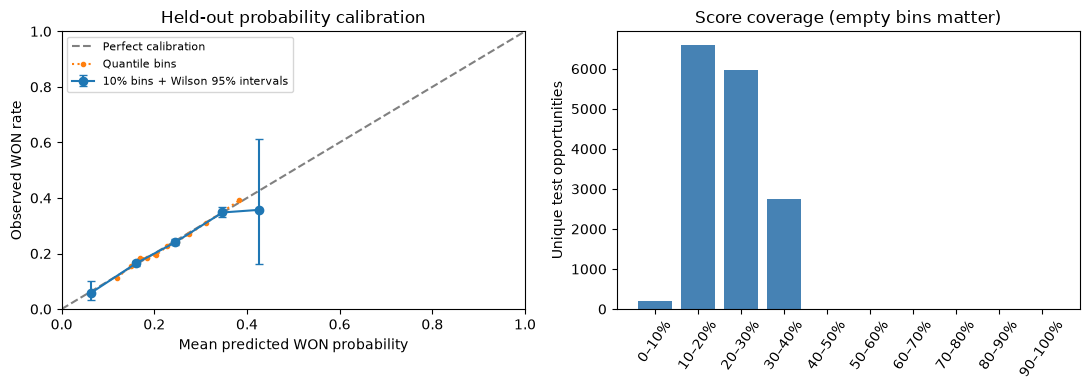

In [14]:
from sklearn.calibration import calibration_curve

bin_labels = [f"{lower}–{lower + 10}%" for lower in range(0, 100, 10)]
test_scores = pd.DataFrame({
    ID: test_df[ID].to_numpy(), "predicted": test_probability, "won": y_test.to_numpy(),
})
assert test_scores[ID].is_unique
assert np.isfinite(test_probability).all() and ((test_probability >= 0) & (test_probability <= 1)).all()
test_scores["probability bin"] = pd.cut(test_scores["predicted"],
    bins=np.linspace(0, 1, 11), labels=bin_labels, include_lowest=True)
calibration_table = test_scores.groupby("probability bin", observed=False).agg(
    opportunities=(ID, "size"), mean_predicted=("predicted", "mean"),
    observed_WON_rate=("won", "mean"))

assert calibration_table["opportunities"].sum() == len(test_df)
n = calibration_table["opportunities"].replace(0, np.nan)
rate = calibration_table["observed_WON_rate"]
z = 1.96
center = (rate + z**2 / (2 * n)) / (1 + z**2 / n)
half_width = z * np.sqrt(rate * (1 - rate) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
calibration_table["observed_95%_low"] = center - half_width
calibration_table["observed_95%_high"] = center + half_width
calibration_table["absolute_gap"] = (rate - calibration_table["mean_predicted"]).abs()
ece = (calibration_table["opportunities"] * calibration_table["absolute_gap"]).sum() / len(test_df)
display(calibration_table.round(4))
print(f"Test mean prediction: {test_probability.mean():.2%}; observed WON rate: {y_test.mean():.2%}")
print(f"10-bin ECE: {ece:.4f} ({100 * ece:.2f} percentage points)")
print("Empty-bin rates are undefined (NaN), not zero.")

populated = calibration_table.loc[calibration_table["opportunities"] > 0]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="Perfect calibration")
axes[0].errorbar(populated["mean_predicted"], populated["observed_WON_rate"],
    yerr=[populated["observed_WON_rate"] - populated["observed_95%_low"],
          populated["observed_95%_high"] - populated["observed_WON_rate"]],
    fmt="o-", capsize=3, label="10% bins + Wilson 95% intervals")
observed_q, predicted_q = calibration_curve(y_test, test_probability, n_bins=10, strategy="quantile")
axes[0].plot(predicted_q, observed_q, ".:", label="Quantile bins")
axes[0].set(xlim=(0, 1), ylim=(0, 1), xlabel="Mean predicted WON probability",
            ylabel="Observed WON rate", title="Held-out probability calibration")
axes[0].legend(fontsize=8)
axes[1].bar(bin_labels, calibration_table["opportunities"], color="steelblue")
axes[1].tick_params(axis="x", rotation=55)
axes[1].set(ylabel="Unique test opportunities", title="Score coverage (empty bins matter)")
plt.tight_layout()
plt.show()

## 11. Genuine held-out opportunities
Select low, middle and high **relative scores** from the test set using predicted probabilities only—not outcomes. Display all three model inputs and the historical result. The conservative model produces no scores above 50%, so “high” here does not mean “likely to win.” These examples illustrate predictions; they do not validate individual probabilities.

In [11]:
example_positions = [int(np.argmin(test_probability)),
    int(np.argmin(np.abs(test_probability - np.median(test_probability)))),
    int(np.argmax(test_probability))]
assert len(set(example_positions)) == 3
heldout_examples = test_df.iloc[example_positions][[ID] + features + [TARGET]].copy()
heldout_examples.insert(0, "score example", ["Low (minimum)", "Middle (near median)", "High (maximum)"])
heldout_examples["predicted WON probability"] = test_probability[example_positions]
heldout_examples["training rows with same inputs"] = [
    int(train_df[features].eq(row[features]).all(axis=1).sum())
    for _, row in heldout_examples.iterrows()
 ]
assert set(heldout_examples[ID]).isdisjoint(train_df[ID])
display(heldout_examples.reset_index(drop=True).round(4))
print("These are real held-out records. IDs and outcomes are displayed for audit only, never model inputs.")

,score example,Opportunity Number,Supplies Subgroup,Region,Route To Market,Opportunity Result,predicted WON probability,training rows with same inputs
0,Low (minimum),6875048,Interior Accessories,Pacific,Telecoverage,Loss,0.0331,46
1,Middle (near median),5524921,Exterior Accessories,Southeast,Fields Sales,Loss,0.2144,345
2,High (maximum),7349654,Tires & Wheels,Midwest,Reseller,Loss,0.4253,46


These are real held-out records. IDs and outcomes are displayed for audit only, never model inputs.


## 12. Manual input and prediction safeguards
Enter an automotive-product example using only categories observed in training. Validate the exact schema, reject missing/unknown categories and reject entirely unseen input combinations for this demonstration. Low training support is explicitly flagged; known categories alone do not establish real-world validity.

The example is hypothetical and has no historical outcome. An unseen-category negative test must **fail before predicting**—a warning followed by a numeric score is not sufficient. No ERP/software/online categories are invented.

In [12]:
encoder = final_pipeline.named_steps["preprocess"].named_transformers_["categorical"].named_steps["encoder"]
known_categories = dict(zip(features, encoder.categories_))

def checked_prediction(inputs):
    if inputs.empty or inputs.columns.has_duplicates or set(inputs.columns) != set(features):
        raise ValueError(f"Supply exactly these nonduplicated feature columns: {features}")
    if inputs.isna().any().any():
        raise ValueError("Missing input: collect the registration information before scoring.")
    for column, allowed in known_categories.items():
        invalid = inputs.loc[~inputs[column].isin(allowed), column].unique().tolist()
        if invalid:
            raise ValueError(f"Unseen values in {column}: {invalid}; no prediction returned.")
    support = [int(train_df[features].eq(row[features]).all(axis=1).sum())
               for _, row in inputs.iterrows()]
    if min(support) == 0:
        raise ValueError("Input combination never seen in training; manual review required.")
    result = inputs[features].copy()
    result["estimated WON probability"] = final_probability(inputs)
    result["training support"] = support
    result["support note"] = ["Limited support: review" if n < 50 else "Observed combination" for n in support]
    return result

manual_input = pd.DataFrame([{
    "Supplies Subgroup": "Exterior Accessories",
    "Region": "Northwest",
    "Route To Market": "Fields Sales",
}])
display(checked_prediction(manual_input).round(4))
print("Manual example: no actual outcome exists; probability is an experimental historical estimate.")

negative_tests = {}
for column in features:
    invalid = manual_input.copy()
    invalid[column] = "__UNSEEN_TEST_VALUE__"
    negative_tests[f"unseen {column}"] = invalid
negative_tests["missing column"] = manual_input.drop(columns=features[0])
negative_tests["extra column"] = manual_input.assign(unexpected_input="invalid")
negative_tests["null input"] = manual_input.copy().assign(Region=None)
for description, invalid in negative_tests.items():
    try:
        checked_prediction(invalid)
    except ValueError as error:
        print(f"PASS — rejected {description}: {error}")
    else:
        raise AssertionError(f"Input validation failed: {description}")

# The pipeline itself must reject unknown categories too, even if the wrapper is bypassed.
try:
    final_probability(negative_tests["unseen Region"])
except ValueError:
    print("PASS — underlying encoder also rejects unknown categories.")
else:
    raise AssertionError("Encoder silently accepted an unknown category")

,Supplies Subgroup,Region,Route To Market,estimated WON probability,training support,support note
0,Exterior Accessories,Northwest,Fields Sales,0.2111,446,Observed combination


Manual example: no actual outcome exists; probability is an experimental historical estimate.
PASS — rejected unseen Supplies Subgroup: Unseen values in Supplies Subgroup: ['__UNSEEN_TEST_VALUE__']; no prediction returned.
PASS — rejected unseen Region: Unseen values in Region: ['__UNSEEN_TEST_VALUE__']; no prediction returned.
PASS — rejected unseen Route To Market: Unseen values in Route To Market: ['__UNSEEN_TEST_VALUE__']; no prediction returned.
PASS — rejected missing column: Supply exactly these nonduplicated feature columns: ['Supplies Subgroup', 'Region', 'Route To Market']
PASS — rejected extra column: Supply exactly these nonduplicated feature columns: ['Supplies Subgroup', 'Region', 'Route To Market']
PASS — rejected null input: Missing input: collect the registration information before scoring.
PASS — underlying encoder also rejects unknown categories.


## 13. Explainability and final checks
Use held-out permutation importance on the **original input columns**, measured as the increase in Brier loss after shuffling one feature. This explains predictive reliance, not causation or percentage-point changes in win probability. Correlated inputs and unrealistic shuffled combinations can affect the result; repeat variability is not a causal confidence interval.

**SHAP review:** the old XGBoost TreeExplainer used raw output (normally log-odds), not probability-point contributions, and explained unsupported categories. It also imported SHAP before its installation cell. Those examples and installation cells are removed. SHAP is not needed for this three-input baseline; permutation importance provides simpler, tested global explainability without another dependency. No local causal explanation is claimed.

,Brier loss increase,repeat SD
feature,,
Supplies Subgroup,0.00555,0.00042
Route To Market,0.00516,0.00056
Region,0.00317,0.00012


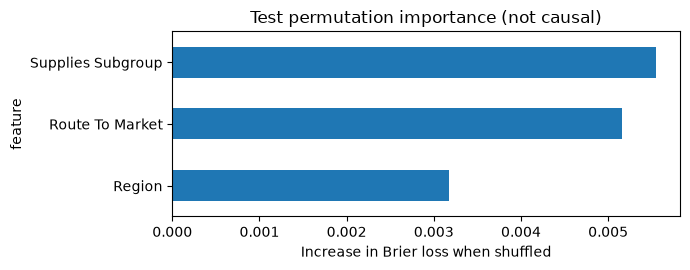

Final checks passed: selected features only; no ID overlap; stable predictions; unique opportunity counts.
All analysis uses the repository CSV. No model artifacts, new app, commits or pushes are created.


In [13]:
from sklearn.inspection import permutation_importance

def probability_quality(estimator, inputs, outcome):
    p = estimator.predict_proba(inputs)[:, 1]
    if final_calibrator is not None:
        p = final_calibrator.predict_proba(log_odds(p))[:, 1]
    return -brier_score_loss(outcome, p)

importance = permutation_importance(final_pipeline, X_test, y_test,
    scoring=probability_quality, n_repeats=5, random_state=SEED, n_jobs=1)
importance_table = pd.DataFrame({
    "feature": features, "Brier loss increase": importance.importances_mean,
    "repeat SD": importance.importances_std,
}).sort_values("Brier loss increase", ascending=False).set_index("feature")
display(importance_table.round(5))
importance_table["Brier loss increase"].sort_values().plot.barh(
    figsize=(7, 2.8), title="Test permutation importance (not causal)")
plt.xlabel("Increase in Brier loss when shuffled")
plt.tight_layout()
plt.show()

excluded_from_primary = set(df.columns) - set(features)
assert not set(features) & {ID, TARGET}
assert set(final_pipeline.feature_names_in_) == set(features)
assert encoder.handle_unknown == "error"
assert np.allclose(final_probability(test_df), test_probability)
assert test_scores[ID].nunique() == len(test_df)
assert all(set(a[ID]).isdisjoint(b[ID]) for a, b in combinations(partitions.values(), 2))
print("Final checks passed: selected features only; no ID overlap; stable predictions; unique opportunity counts.")
print("All analysis uses the repository CSV. No model artifacts, new app, commits or pushes are created.")

## Dataset Viability Assessment

**A. What exactly can this dataset predict?**
Historical `Won` versus `Loss` for resolved sales opportunities in the automotive/accessory categories represented here. The primary model uses proposed product subgroup, region and sales route at an **assumed registration point**, scoped to single-record opportunities. It does not demonstrate prospective prediction at creation because there are no dated feature snapshots.

**B. What business decision could it support?**
Experimental prioritization of opportunities for human sales review and comparison of historical segment win rates. Any follow-up rules should be explicit policies (for example, reject unsupported inputs or request missing information), not learned claims about which intervention increases wins. Costs/capacity are absent, so the F1 threshold is illustrative, not a recommended business policy.

**C. What should the prediction NOT be claimed to mean?**
Not a guarantee, causal effect, individual certainty, expected profit, sales-cycle forecast or validated new-customer score. It does not estimate advertising impact, email/SMS effectiveness, campaign uplift, optimal follow-up channel or the benefit of changing sales route. Results do not establish transfer to software/ERP or other industries.

**D. Are the probabilities sufficiently calibrated to display?**
For a clearly labelled **academic historical-data demonstration**, yes within supported inputs and well-populated score ranges, with caveats; not yet for operational deployment. The selected raw Random Forest has test Brier **0.1689** versus **0.1745** for prevalence, only **3.19% Brier skill**. Mean prediction **22.54%** matches observed **22.52%**; 10-bin ECE is **0.39 percentage points**. Sigmoid calibration did not improve validation Brier, so it was not retained. The score range is **3.3–42.5%**; only **14** test opportunities populate 40–50%, and no bin above 50% is populated. A 63% example would therefore be unsupported. Good aggregate calibration does not imply strong discrimination or proven subgroup/individual reliability.

**E. Major limitations**
- No data dictionary, source/provenance citation, collection period, sampling description or license is documented in this repository; verify before publication. The IBM-labelled filename alone does not establish authenticity or whether records are real/synthetic.
- No creation/closing/snapshot dates, customer IDs, new-customer flag or intervention history. Cannot validate temporal drift, customer independence, new-customer generalization or action effectiveness.
- Amount, customer profile/history bands and competitor timing/semantics are unverified. Strong associations could reflect real history, export artifacts or later updates; performance cannot settle this.
- **78,025 × 19**, no blank missing values, **55 exact duplicates**. After deduplication, **137 IDs / 278 rows** remain ambiguous, consistent with line items but unconfirmed; excluded rather than aggregated arbitrarily. Their WON rate is **35.04%**, versus **22.52%** retained, so exclusion narrows applicability.
- The **77,692** retained opportunities are imbalanced (17,500 Won / 60,192 Loss), limited to resolved records; no evidence that live unresolved opportunities follow the same distribution.
- Conservative test ranking is modest: **ROC-AUC 0.6188** (bootstrap 95% interval **0.6078–0.6301**), **PR-AUC/AP 0.3105** versus prevalence **0.2252**. At the validation-selected threshold **0.1844**, precision **0.2656**, recall **0.7523**, F1 **0.3926**; many flagged records are losses. At 0.5 the model predicts no wins.
- One grouped random split, fixed baseline hyperparameters and no external validation. Bootstrap intervals reflect test sampling only. Unknown categorical values are rejected, not silently scored.

**F. Is it defensible for a final academic project?**
**RETAIN conditionally for a bounded, transparent applied-ML study; reject strong claims of deployment-ready early-stage scoring.** There is measurable but modest registration-time signal and a useful calibration/leakage study. The same Random Forest reaches validation ROC-AUC **0.8206** with amount and history assumptions (versus **0.6125** primary), but those features are not approved merely because they score better. Confirm provenance, usage rights and feature timing with a documented source/domain expert before presenting an operational system. If those cannot be established, retain only as an explicitly limited educational benchmark, not validated business evidence.

**G. Suitable project title/problem and directions**
1. **Leakage-Aware Probability Estimation for Automotive Sales Opportunities** — compare conservative registration inputs with explicitly conditional feature sets; quantify ranking, calibration and limitations.
2. **Historical Sales Opportunity Review Dashboard** — a small Streamlit demonstration showing experimental probabilities, support counts and historical segment outcomes; deterministic input-quality/manual-review rules, without claims of intervention benefit.
3. **Feature Availability and Calibration in Sales Win/Loss Prediction** — an evaluation-focused capstone on the cost of assuming amount/history/competitor availability and the distinction between calibrated probabilities and useful prioritization.

**Execution scope:** all 13 code cells were executed successfully in the connected local VS Code Python kernel. XGBoost was not installed and is explicitly skipped (optional code path not tested); SHAP was removed in favour of executed permutation importance. Colab execution was not tested. Important tables/plots are retained in this notebook. No replacement dataset search, application redesign, commit or push was performed.

# Dataset Behaviour Audit

**Scope:** append-only development analysis. The original evaluation above is preserved. Amount, history and other candidate fields are investigated, not newly approved as prediction-time-safe. No test-set predictions or tuning are performed below.

**Load -> Existing baseline -> Feature importance -> Observed relationships -> SHAP -> Ablation -> Segment evaluation -> Findings**

## Load
Recreate the original cleaned population and deterministic split with the same CSV fingerprint, library versions and seeds. Use separate `audit_` variables so earlier results are not replaced.

In [1]:
from pathlib import Path
from importlib.metadata import version
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

AUDIT_SEED = 42
audit_root = next(parent for parent in (Path.cwd(), *Path.cwd().parents)
                  if (parent / "datasets/IBM-sales-opportunity.csv").is_file())
audit_path = audit_root / "datasets/IBM-sales-opportunity.csv"
assert hashlib.sha256(audit_path.read_bytes()).hexdigest() == (
    "31afdb83aa46b54f62f5cdbfe1ccf00f395266254a0249c96ceef8522cc12b24"
), "Dataset differs from the saved evaluation."
audit_raw = pd.read_csv(audit_path, keep_default_na=False, na_values=[""])
audit_unique = audit_raw.drop_duplicates()
audit_ambiguous = audit_unique["Opportunity Number"].duplicated(keep=False)
audit_data = audit_unique.loc[~audit_ambiguous].copy()
audit_data["won"] = audit_data["Opportunity Result"].map({"Won": 1, "Loss": 0})
assert len(audit_raw) == 78025 and len(audit_data) == 77692
assert audit_data["Opportunity Number"].is_unique and audit_data["won"].notna().all()
assert audit_data["won"].sum() == 17500
print("Same CSV and cleaning: 77,692 unique opportunities; 17,500 Won / 60,192 Loss.")
print("Earlier notebook cells and saved results are preserved; no test scoring in this audit.")
display(pd.DataFrame({"package": ["numpy", "pandas", "scikit-learn", "matplotlib"],
                      "version": [version(package) for package in
                                  ["numpy", "pandas", "scikit-learn", "matplotlib"]]}))

Same CSV and cleaning: 77,692 unique opportunities; 17,500 Won / 60,192 Loss.
Earlier notebook cells and saved results are preserved; no test scoring in this audit.


,package,version
0,numpy,2.5.3
1,pandas,3.0.6
2,scikit-learn,1.9.1
3,matplotlib,3.11.2


In [2]:
from itertools import combinations
from sklearn.model_selection import StratifiedGroupKFold

audit_core = ["Supplies Subgroup", "Region", "Route To Market"]
audit_profiles = ["Client Size By Revenue", "Client Size By Employee Count"]
audit_amount = "Opportunity Amount USD"
audit_history = "Revenue From Client Past Two Years"
audit_competitor = "Competitor Type"
audit_candidates = audit_core + audit_profiles + [audit_amount, audit_history, audit_competitor]

def audit_holdout(frame, folds, seed):
    splitter = StratifiedGroupKFold(n_splits=folds, shuffle=True, random_state=seed)
    keep, holdout = next(splitter.split(frame[audit_core], frame["won"],
                                       groups=frame["Opportunity Number"]))
    return frame.iloc[keep].copy(), frame.iloc[holdout].copy()

audit_development, audit_reserved = audit_holdout(audit_data, 5, AUDIT_SEED)
audit_fit, audit_validation = audit_holdout(audit_development, 4, AUDIT_SEED + 1)
audit_train, audit_calibration = audit_holdout(audit_fit, 6, AUDIT_SEED + 2)
audit_partitions = {"train": audit_train, "calibration": audit_calibration,
                    "validation": audit_validation, "reserved test": audit_reserved}
assert [len(frame) for frame in audit_partitions.values()] == [38846, 7769, 15538, 15539]
for left, right in combinations(audit_partitions.values(), 2):
    assert set(left["Opportunity Number"]).isdisjoint(right["Opportunity Number"])
display(pd.DataFrame([
    {"partition": name, "opportunities": len(frame),
     "ID checksum": hashlib.sha256(frame["Opportunity Number"].to_numpy().tobytes()).hexdigest()[:16]}
    for name, frame in audit_partitions.items()
 ]))
print("Original grouped split recreated. Reserved test will not be predicted or evaluated.")

,partition,opportunities,ID checksum
0,train,38846,e96b5a88be566315
1,calibration,7769,669b75305a6982f6
2,validation,15538,9dcb28c87a08dfe5
3,reserved test,15539,c75cee5e918657ea


Original grouped split recreated. Reserved test will not be predicted or evaluated.


## Existing Baseline

Use the original Random Forest settings and preprocessing. Reproduce the conservative and seven-field results, then use the full eight-field model for diagnostics so competitor information is tested rather than assumed useful. All reported results below are validation results; higher performance does not approve feature timing.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

audit_rf_settings = dict(n_estimators=200, max_depth=12, min_samples_leaf=30,
                         max_features=0.8, n_jobs=2, random_state=AUDIT_SEED)
audit_band_edges = [1, 10000, 25000, 50000, 100000, 250000, 500000]

def audit_pipeline(columns, amount_mode="log", estimator=None):
    categorical = [column for column in columns if column != audit_amount]
    transforms = []
    if categorical:
        transforms.append(("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="error", sparse_output=False)),
        ]), categorical))
    if audit_amount in columns:
        steps = [("imputer", SimpleImputer(strategy="median"))]
        if amount_mode == "bands":
            steps += [("bands", FunctionTransformer(np.digitize, kw_args={"bins": audit_band_edges})),
                      ("encoder", OneHotEncoder(handle_unknown="error", sparse_output=False))]
        else:
            if amount_mode == "log":
                steps.append(("log1p", FunctionTransformer(np.log1p)))
            steps.append(("scale", StandardScaler()))
        transforms.append(("amount", Pipeline(steps), [audit_amount]))
    if estimator is None:
        estimator = RandomForestClassifier(**audit_rf_settings)
    return Pipeline([("preprocess", ColumnTransformer(transforms)), ("model", estimator)])

def audit_quality(actual, probability):
    return {"ROC_AUC": roc_auc_score(actual, probability) if actual.nunique() == 2 else np.nan,
            "AP": average_precision_score(actual, probability) if actual.sum() else np.nan,
            "Brier": brier_score_loss(actual, probability)}

audit_models, audit_baseline_rows = {}, []
for name, columns in [("Conservative", audit_core),
                      ("Seven-field", audit_candidates[:-1]),
                      ("Full eight-field", audit_candidates)]:
    fitted = audit_pipeline(columns).fit(audit_train[columns], audit_train["won"])
    probability = fitted.predict_proba(audit_validation[columns])[:, 1]
    audit_models[name] = fitted
    audit_baseline_rows.append({"model": name, **audit_quality(audit_validation["won"], probability)})
audit_full = audit_models["Full eight-field"]
audit_probability = audit_full.predict_proba(audit_validation[audit_candidates])[:, 1]
audit_baseline = pd.DataFrame(audit_baseline_rows).set_index("model")
assert abs(audit_baseline.loc["Seven-field", "ROC_AUC"] - 0.8206) < 0.0001
assert abs(audit_baseline.loc["Full eight-field", "ROC_AUC"] - 0.8195) < 0.0001
display(audit_baseline.round(4))
print("Training-prevalence baseline:", audit_quality(audit_validation["won"],
      np.full(len(audit_validation), audit_train["won"].mean())))

,ROC_AUC,AP,Brier
model,,,
Conservative,0.6125,0.3067,0.1694
Seven-field,0.8206,0.5978,0.1292
Full eight-field,0.8195,0.5984,0.1294


Training-prevalence baseline: {'ROC_AUC': 0.5, 'AP': 0.22525421547174668, 'Brier': 0.17451475391757892}


## Feature Importance

Diagnose the fixed eight-field Random Forest. Tree-path-dependent SHAP is descriptive, not causal; verify that SHAP contributions sum to the model's **Won probability**, not log-odds. Sum one-hot contributions within each business field before taking mean absolute importance. SHAP uses 600 fixed random validation rows; permutation uses a separate fixed 3,000-row validation sample and five shuffles. Native impurity importance can favor continuous/high-cardinality inputs.

In [4]:
import shap

print("SHAP version:", shap.__version__)
audit_shap_sample = audit_validation.sample(n=600, random_state=AUDIT_SEED)
audit_preprocessor = audit_full.named_steps["preprocess"]
audit_forest = audit_full.named_steps["model"]
audit_encoded = audit_preprocessor.transform(audit_shap_sample[audit_candidates])
audit_categorical = [column for column in audit_candidates if column != audit_amount]
audit_encoder = audit_preprocessor.named_transformers_["categorical"].named_steps["encoder"]
audit_encoded_owner = np.repeat(audit_categorical, [len(levels) for levels in audit_encoder.categories_]).tolist()
audit_encoded_owner += [audit_amount]
audit_encoded_owner = np.asarray(audit_encoded_owner)
assert len(audit_encoded_owner) == audit_encoded.shape[1]

audit_explainer = shap.TreeExplainer(audit_forest, feature_perturbation="tree_path_dependent")
audit_shap_raw = audit_explainer.shap_values(audit_encoded, check_additivity=True)
audit_shap_won = (audit_shap_raw[1] if isinstance(audit_shap_raw, list)
                  else np.asarray(audit_shap_raw)[:, :, 1])
audit_shap_base = float(np.asarray(audit_explainer.expected_value)[1])
np.testing.assert_allclose(audit_shap_base + audit_shap_won.sum(axis=1),
                           audit_forest.predict_proba(audit_encoded)[:, 1], atol=1e-6)
audit_shap_business = pd.DataFrame({
    column: audit_shap_won[:, audit_encoded_owner == column].sum(axis=1)
    for column in audit_candidates
}, index=audit_shap_sample.index)
np.testing.assert_allclose(audit_shap_business.sum(axis=1), audit_shap_won.sum(axis=1), atol=1e-10)
print("SHAP additivity passed in Won-probability units; baseline:", round(audit_shap_base, 4))
display(audit_shap_business.abs().mean().sort_values(ascending=False).to_frame("mean_abs_SHAP"))

/home/emmanuel/.venvs/opportunity-scoring/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.52.0
SHAP additivity passed in Won-probability units; baseline: 0.225


,mean_abs_SHAP
Revenue From Client Past Two Years,0.092643
Opportunity Amount USD,0.087807
Route To Market,0.031101
Competitor Type,0.012711
Region,0.009461
Supplies Subgroup,0.007048
Client Size By Revenue,0.002254
Client Size By Employee Count,0.002169


In [5]:
from sklearn.inspection import permutation_importance

audit_perm_sample = audit_validation.sample(n=3000, random_state=AUDIT_SEED + 10)
audit_permutation = permutation_importance(
    audit_full, audit_perm_sample[audit_candidates], audit_perm_sample["won"],
    scoring={"Brier": "neg_brier_score", "AUC": "roc_auc"},
    n_repeats=5, random_state=AUDIT_SEED, n_jobs=1,
 )
audit_native = pd.Series(audit_forest.feature_importances_, index=audit_encoded_owner).groupby(level=0).sum()
audit_importance = pd.DataFrame({
    "SHAP_mean_abs": audit_shap_business.abs().mean(),
    "Permutation_Brier_increase": pd.Series(audit_permutation["Brier"].importances_mean, index=audit_candidates),
    "Permutation_Brier_SD": pd.Series(audit_permutation["Brier"].importances_std, index=audit_candidates),
    "Permutation_AUC_drop": pd.Series(audit_permutation["AUC"].importances_mean, index=audit_candidates),
    "Native_importance": audit_native,
}).sort_values("SHAP_mean_abs", ascending=False)
audit_importance["Interpretation"] = pd.Series({
    audit_history: "History-code association; zero is not a customer type.",
    audit_amount: "Deal-value relationship; inspect direction and extremes.",
    "Route To Market": "Sales-route association, not an optimal-channel recommendation.",
    "Region": "Territory association; transfer requires validation.",
    "Supplies Subgroup": "Conditional product contribution; test by removal.",
    "Client Size By Revenue": "Coarse client size, not prior seller-client revenue.",
    "Client Size By Employee Count": "Coarse headcount; test joint profile removal.",
    audit_competitor: "Model reliance may differ from incremental model benefit.",
})
audit_importance.index.name = "Feature"
display(audit_importance.round(5))
print("Methods have different scales; permutation SD is shuffle variability, not a confidence interval.")

,SHAP_mean_abs,Permutation_Brier_increase,Permutation_Brier_SD,Permutation_AUC_drop,Native_importance,Interpretation
Feature,,,,,,
Revenue From Client Past Two Years,0.09264,0.04652,0.00220,0.11402,0.42451,History-code association; zero is not a custom...
Opportunity Amount USD,0.08781,0.03292,0.00175,0.14570,0.43096,Deal-value relationship; inspect direction and...
Route To Market,0.03110,0.00570,0.00058,0.03063,0.05000,"Sales-route association, not an optimal-channe..."
Competitor Type,0.01271,0.00095,0.00026,0.00564,0.02264,Model reliance may differ from incremental mod...
Region,0.00946,0.00082,0.00036,0.00326,0.02950,Territory association; transfer requires valid...
Supplies Subgroup,0.00705,0.00084,0.00031,0.00442,0.02707,Conditional product contribution; test by remo...
Client Size By Revenue,0.00225,0.00011,0.00008,0.00014,0.00819,"Coarse client size, not prior seller-client re..."
Client Size By Employee Count,0.00217,-0.00018,0.00005,-0.00050,0.00713,Coarse headcount; test joint profile removal.


Methods have different scales; permutation SD is shuffle variability, not a confidence interval.


## Observed Relationships

Compare actual outcomes with model probabilities on the full validation partition and observed training win rates. Category differences can reflect case mix, not isolated effects. Client/history codes remain nominal categories. `Supplies Group` is a redundant descriptive grouping, not another predictor. Signed SHAP means use the 600-row sample; absence of a category there is not evidence of zero effect.

In [6]:
audit_observed = audit_validation.assign(probability=audit_probability)
audit_observed["squared_error"] = (audit_observed["probability"] - audit_observed["won"]) ** 2
audit_category_tables = {}
assert audit_data.groupby("Supplies Subgroup")["Supplies Group"].nunique().eq(1).all()
for column in audit_categorical + ["Supplies Group"]:
    summary = audit_observed.groupby(column, observed=True, dropna=False).agg(
        Opportunities=("won", "size"), Wins=("won", "sum"),
        Observed_win_rate=("won", "mean"), Average_probability=("probability", "mean"),
        Brier=("squared_error", "mean"),
    )
    summary.insert(2, "Losses", summary["Opportunities"] - summary["Wins"])
    summary["Training_win_rate"] = audit_train.groupby(column, observed=True)["won"].mean()
    if column in audit_shap_business:
        summary["SHAP_sample_n"] = audit_shap_sample.groupby(column, observed=True).size()
        summary["Mean_signed_SHAP"] = audit_shap_business[column].groupby(audit_shap_sample[column]).mean()
    audit_category_tables[column] = summary
    assert summary["Opportunities"].sum() == len(audit_validation)
    print(column)
    display(summary.round(4))

print("History versus client revenue size: training counts, not a correlation of arbitrary codes")
audit_history_profile = pd.crosstab(audit_train[audit_history], audit_train["Client Size By Revenue"])
display(audit_history_profile)
print("Distinct client-size codes within each history code:")
display(audit_train.groupby(audit_history)[audit_profiles].nunique())

Supplies Subgroup


,Opportunities,Wins,Losses,Observed_win_rate,Average_probability,Brier,Training_win_rate,SHAP_sample_n,Mean_signed_SHAP
Supplies Subgroup,,,,,,,,,
Batteries & Accessories,1795,390,1405,0.2173,0.2060,0.1317,0.2016,68,-0.0061
Car Electronics,56,16,40,0.2857,0.1717,0.1841,0.2701,1,0.0002
Exterior Accessories,2816,726,2090,0.2578,0.2489,0.1413,0.2544,111,0.0068
Garage & Car Care,1960,573,1387,0.2923,0.2801,0.1670,0.2805,72,0.0020
Interior Accessories,1083,166,917,0.1533,0.1648,0.0980,0.1607,44,-0.0056
Motorcycle Parts,2988,693,2295,0.2319,0.2394,0.1260,0.2388,117,0.0048
Performance Parts,550,99,451,0.1800,0.1780,0.1106,0.1598,29,-0.0056
Replacement Parts,1475,390,1085,0.2644,0.2595,0.1422,0.2660,52,-0.0016
Shelters & RV,1951,316,1635,0.1620,0.1786,0.1022,0.1862,76,-0.0042


Region


,Opportunities,Wins,Losses,Observed_win_rate,Average_probability,Brier,Training_win_rate,SHAP_sample_n,Mean_signed_SHAP
Region,,,,,,,,,
Mid-Atlantic,1509,319,1190,0.2114,0.2126,0.1222,0.2198,58,-0.0022
Midwest,4202,1073,3129,0.2554,0.2481,0.1362,0.2489,152,0.0147
Northeast,1420,283,1137,0.1993,0.2155,0.1166,0.2234,68,0.0005
Northwest,1952,404,1548,0.2070,0.2354,0.1285,0.2193,79,-0.0132
Pacific,2996,694,2302,0.2316,0.2183,0.1353,0.2221,114,-0.0019
Southeast,1835,399,1436,0.2174,0.2153,0.1262,0.2233,71,-0.0009
Southwest,1624,328,1296,0.2020,0.1919,0.1237,0.1871,58,-0.0070


Route To Market


...

,Opportunities,Wins,Losses,Observed_win_rate,Average_probability,Brier,Training_win_rate
Supplies Group,,,,,,,
Car Accessories,9878,2360,7518,0.2389,0.2333,0.1370,0.2330
Car Electronics,56,16,40,0.2857,0.1717,0.1841,0.2701
Performance & Non-auto,5489,1108,4381,0.2019,0.2116,0.1160,0.2133
Tires & Wheels,115,16,99,0.1391,0.1201,0.0926,0.1175


History versus client revenue size: training counts, not a correlation of arbitrary codes


Client Size By Revenue,1,2,3,4,5
Revenue From Client Past Two Years,,,,,
0,26413,1731,2160,1973,2192
1,668,48,58,74,32
2,797,51,42,91,56
3,799,48,47,58,91
4,1014,47,45,79,232


Distinct client-size codes within each history code:


,Client Size By Revenue,Client Size By Employee Count
Revenue From Client Past Two Years,,
0,5,5
1,5,5
2,5,5
3,5,5
4,5,5


,Opportunities,Wins,Losses,Observed_win_rate,Mean_amount,Median_amount,Average_probability,Brier,Probability_ge_80pct,Training_win_rate
amount_band,,,,,,,,,,
Zero,388,60,328,0.1546,0.0000,0.0,0.1747,0.1185,0.0000,0.1524
"1-9,999",1963,868,1095,0.4422,4299.2420,4650.0,0.4467,0.2116,0.0968,0.4551
"10,000-24,999",2966,793,2173,0.2674,15754.0829,15000.0,0.2624,0.1446,0.0496,0.2648
"25,000-49,999",2389,558,1831,0.2336,33602.0063,30674.0,0.2489,0.1390,0.0322,0.2499
"50,000-99,999",2770,482,2288,0.1740,63547.0776,60000.0,0.1717,0.1065,0.0061,0.1724
"100,000-249,999",3605,459,3146,0.1273,139414.9318,125000.0,0.1169,0.0855,0.0003,0.1149
"250,000-499,999",974,169,805,0.1735,328664.7372,300000.0,0.1791,0.1188,0.0000,0.1762
"500,000+",483,111,372,0.2298,658304.1159,600000.0,0.2078,0.1442,0.0000,0.1799


Bands use the existing deal-size boundaries, with zero separate; not tuned to outcomes.
80% is a diagnostic probability cutoff, not a priority rule.


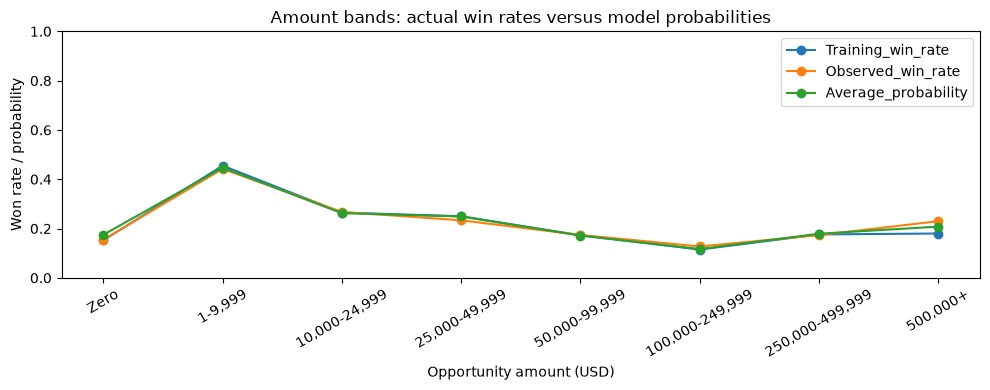

,Opportunities,Median_amount,Mean_amount,Observed_win_rate,History_zero_fraction
Predicted probability >= 80%,,,,,
False,15106,50000.0,95641.5562,0.2077,0.9102
True,432,12084.0,17075.0995,0.8403,0.0069


In [7]:
audit_band_labels = ["Zero", "1-9,999", "10,000-24,999", "25,000-49,999",
                     "50,000-99,999", "100,000-249,999", "250,000-499,999", "500,000+"]
audit_observed["amount_band"] = pd.Categorical.from_codes(
    np.digitize(audit_observed[audit_amount], audit_band_edges), audit_band_labels, ordered=True)
audit_training_bands = pd.Categorical.from_codes(
    np.digitize(audit_train[audit_amount], audit_band_edges), audit_band_labels, ordered=True)
audit_observed["high_probability"] = audit_observed["probability"].ge(0.8)
audit_amount_table = audit_observed.groupby("amount_band", observed=True).agg(
    Opportunities=("won", "size"), Wins=("won", "sum"), Observed_win_rate=("won", "mean"),
    Mean_amount=(audit_amount, "mean"), Median_amount=(audit_amount, "median"),
    Average_probability=("probability", "mean"), Brier=("squared_error", "mean"),
    Probability_ge_80pct=("high_probability", "mean"),
 )
audit_amount_table.insert(2, "Losses", audit_amount_table["Opportunities"] - audit_amount_table["Wins"])
audit_amount_table["Training_win_rate"] = audit_train.groupby(audit_training_bands, observed=True)["won"].mean()
assert audit_amount_table["Opportunities"].sum() == len(audit_validation)
display(audit_amount_table.round(4))
print("Bands use the existing deal-size boundaries, with zero separate; not tuned to outcomes.")
print("80% is a diagnostic probability cutoff, not a priority rule.")

axis = audit_amount_table[["Training_win_rate", "Observed_win_rate", "Average_probability"]].plot(
    marker="o", figsize=(10, 4), ylim=(0, 1), title="Amount bands: actual win rates versus model probabilities")
axis.set(xlabel="Opportunity amount (USD)", ylabel="Won rate / probability")
axis.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

audit_amount_summary = audit_observed.groupby(audit_observed["probability"].ge(0.8)).agg(
    Opportunities=("won", "size"), Median_amount=(audit_amount, "median"),
    Mean_amount=(audit_amount, "mean"), Observed_win_rate=("won", "mean"),
    History_zero_fraction=(audit_history, lambda values: values.eq(0).mean()),
 )
display(audit_amount_summary.rename_axis("Predicted probability >= 80%").round(4))

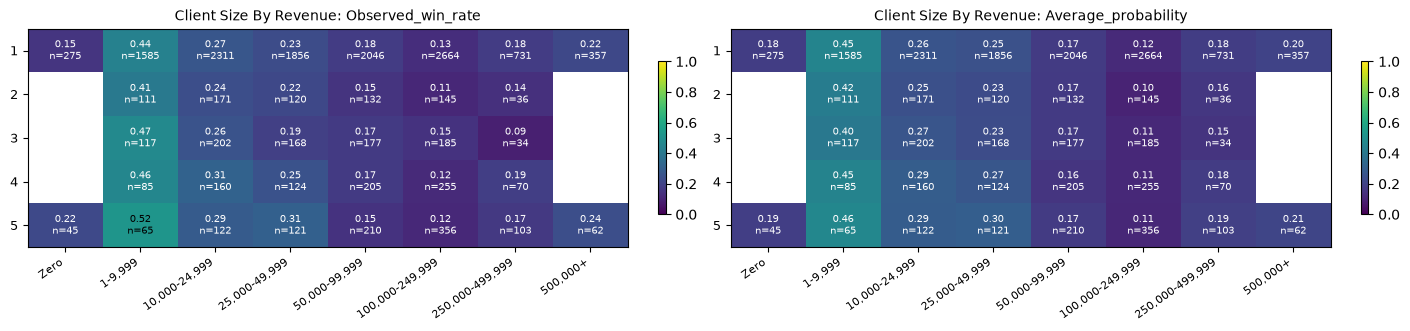

Client Size By Revenue | supported cells: 34 | largest absolute train/validation differences:


Opportunities  Wins  \
Client Size By Revenue amount_band                            
3                      250,000-499,999             34     3   
                       25,000-49,999              168    32   
4                      250,000-499,999             70    13   

                                        Observed_win_rate  \
Client Size By Revenue amount_band                          
3                      250,000-499,999             0.0882   
                       25,000-49,999               0.1905   
4                      250,000-499,999             0.1857   

                                        Average_probability  \
Client Size By Revenue amount_band                            
3                      250,000-499,999               0.1488   
                       25,000-49,999                 0.2311   
4                      250,000-499,999               0.1763   

                                        Training_win_rate  Training_n  \
Client Size By Revenue amount_band                                      
3                      250,000-499,999             0.1827         104   
                       25,000-49,999               0.2629         388   
4                      250,000-499,999             0.1198         167   

                                        validation_minus_training  
Client Size By Revenue amount_band                                 
3                      250,000-499,999                    -0.0945  
                       25,000-49,999                      -0.0724  
4                      250,000-499,999                     0.0660

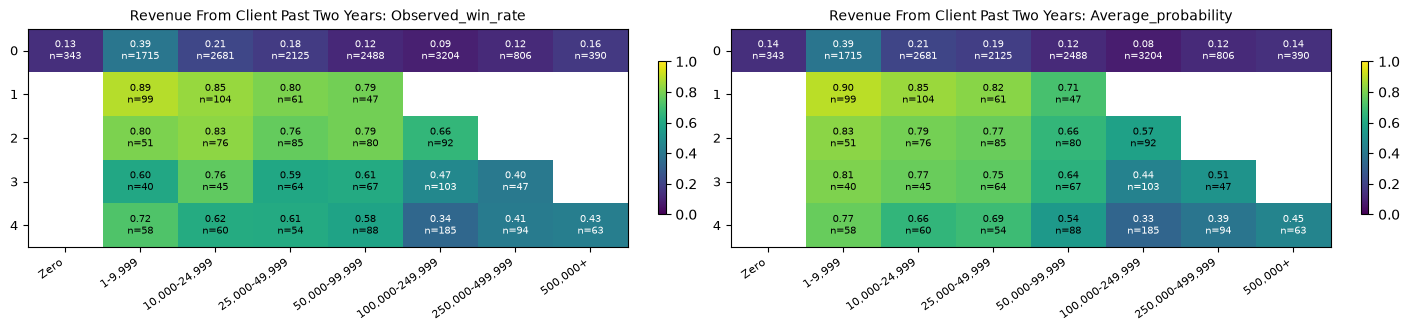

Revenue From Client Past Two Years | supported cells: 30 | largest absolute train/validation differences:


Opportunities  Wins  \
Revenue From Client Past Two Years amount_band                            
3                                  1-9,999                     40    24   
                                   25,000-49,999               64    38   
                                   250,000-499,999             47    19   

                                                    Observed_win_rate  \
Revenue From Client Past Two Years amount_band                          
3                                  1-9,999                     0.6000   
                                   25,000-49,999               0.5938   
                                   250,000-499,999             0.4043   

                                                    Average_probability  \
Revenue From Client Past Two Years amount_band                            
3                                  1-9,999                       0.8064   
                                   25,000-49,999                 0.7518   
                                   250,000-499,999               0.5139   

                                                    Training_win_rate  \
Revenue From Client Past Two Years amount_band                          
3                                  1-9,999                     0.8347   
                                   25,000-49,999               0.7557   
                                   250,000-499,999             0.5054   

                                                    Training_n  \
Revenue From Client Past Two Years amount_band                   
3                                  1-9,999                 121   
                                   25,000-49,999           131   
                                   250,000-499,999          93   

                                                    validation_minus_training  
Revenue From Client Past Two Years amount_band                                 
3                                  1-9,999                            -0.2347  
                                   25,000-49,999                      -0.1620  
                                   250,000-499,999                    -0.1011

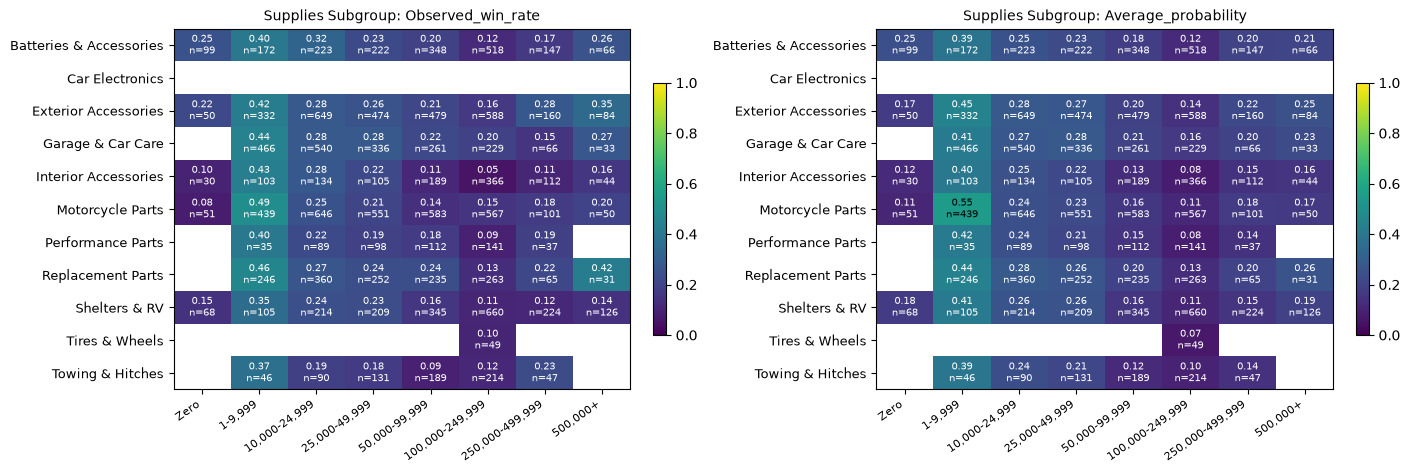

Supplies Subgroup | supported cells: 67 | largest absolute train/validation differences:


,,Opportunities,Wins,Observed_win_rate,Average_probability,Training_win_rate,Training_n,validation_minus_training
Supplies Subgroup,amount_band,,,,,,,
Replacement Parts,"500,000+",31,13,0.4194,0.2575,0.2632,57,0.1562
Towing & Hitches,"250,000-499,999",47,11,0.2340,0.1431,0.1140,114,0.1200
Exterior Accessories,"500,000+",84,29,0.3452,0.2488,0.2364,165,0.1089


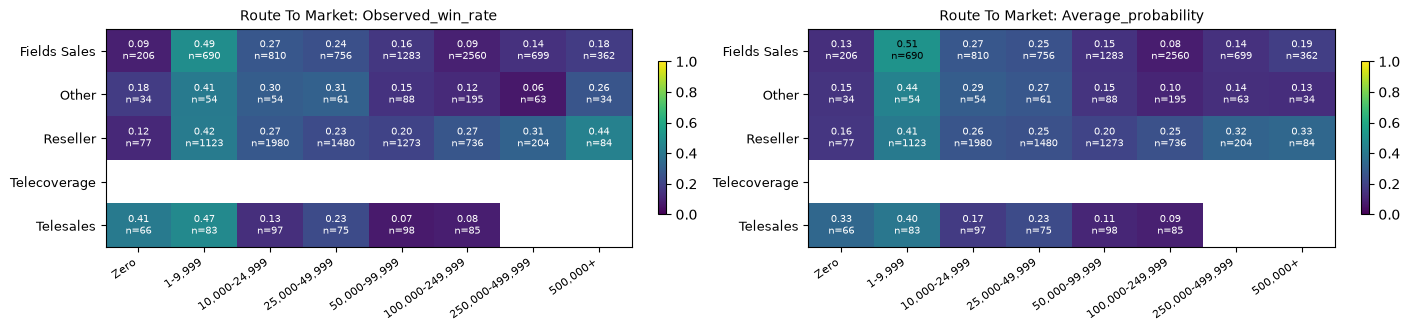

Route To Market | supported cells: 30 | largest absolute train/validation differences:


,,Opportunities,Wins,Observed_win_rate,Average_probability,Training_win_rate,Training_n,validation_minus_training
Route To Market,amount_band,,,,,,,
Other,"500,000+",34,9,0.2647,0.1328,0.1148,61,0.1500
Reseller,"500,000+",84,37,0.4405,0.3326,0.3035,201,0.1370
Other,"250,000-499,999",63,4,0.0635,0.1364,0.1269,134,-0.0634


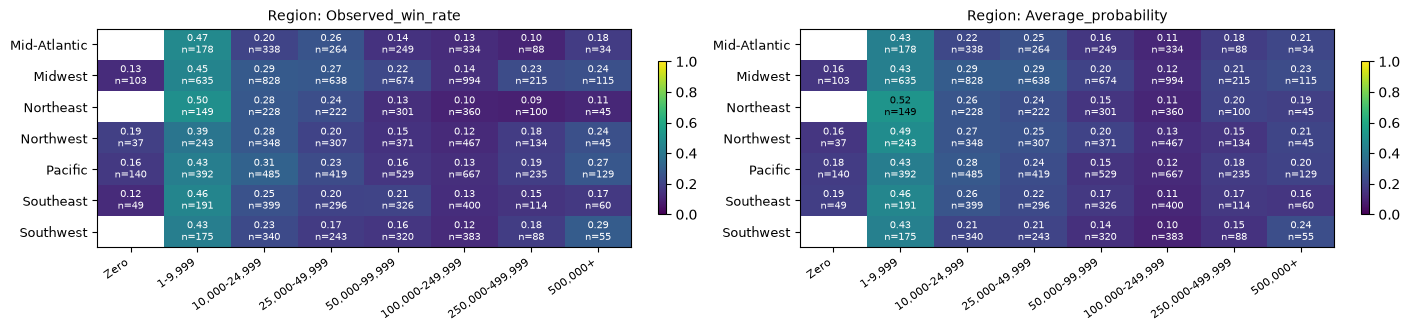

Region | supported cells: 53 | largest absolute train/validation differences:


,,Opportunities,Wins,Observed_win_rate,Average_probability,Training_win_rate,Training_n,validation_minus_training
Region,amount_band,,,,,,,
Northwest,"500,000+",45,11,0.2444,0.2098,0.1224,147,0.1220
Southwest,"500,000+",55,16,0.2909,0.2409,0.1930,114,0.0979
Northwest,Zero,37,7,0.1892,0.1571,0.0928,97,0.0964


History x client revenue size: validation outcomes


Opportunities  \
Revenue From Client Past Two Years Client Size By Revenue                  
0                                  1                               10460   
                                   2                                 692   
                                   3                                 854   
                                   4                                 847   
                                   5                                 899   
1                                  1                                 263   
                                   2                                  18   
                                   3                                  23   
                                   4                                  21   
                                   5                                  19   
2                                  1                                 325   
                                   2                                  16   
                                   3                                  18   
                                   4                                  34   
                                   5                                  34   
3                                  1                                 298   
                                   2                                  17   
                                   3                                  15   
                                   4                                  24   
                                   5                                  36   
4                                  1                                 479   
                                   2                                  12   
                                   3                                  15   
                                   4                                  23   
                                   5                                  96   

                                                           Observed_win_rate  \
Revenue From Client Past Two Years Client Size By Revenue                      
0                                  1                                  0.1736   
                                   2                                  0.1705   
                                   3                                  0.1967   
                                   4                                  0.1795   
                                   5                                  0.1535   
1                                  1                                  0.8403   
                                   2                                  0.9444   
                                   3                                  0.5217   
                                   4                                  0.6667   
                                   5                                  0.7368   
2                                  1                                  0.7723   
                                   2                                  0.7500   
                                   3                                  0.7222   
                                   4                                  0.6765   
                                   5                                  0.4706   
3                                  1                                  0.5705   
                                   2                                  0.5882   
                                   3                                  0.5333   
                                   4                                  0.5000   
                                   5                                  0.4722   
4                                  1                                  0.5115   
                                   2                                  0.4167   
                                   3                                  0.4000   
      

Blank heatmap cells have fewer than 30 validation records. These are conditional associations, not causal interactions.


In [8]:
audit_interaction_tables = {}
audit_training_view = audit_train.assign(amount_band=audit_training_bands)
for column in ["Client Size By Revenue", audit_history, "Supplies Subgroup", "Route To Market", "Region"]:
    grouped = audit_observed.groupby([column, "amount_band"], observed=True).agg(
        Opportunities=("won", "size"), Wins=("won", "sum"),
        Observed_win_rate=("won", "mean"), Average_probability=("probability", "mean"),
    )
    grouped["Training_win_rate"] = audit_training_view.groupby([column, "amount_band"], observed=True)["won"].mean()
    grouped["Training_n"] = audit_training_view.groupby([column, "amount_band"], observed=True).size()
    audit_interaction_tables[column] = grouped
    counts = grouped["Opportunities"].unstack("amount_band").reindex(columns=audit_band_labels).fillna(0)
    figure, axes = plt.subplots(1, 2, figsize=(14, max(3.2, 0.42 * len(counts))), constrained_layout=True)
    for axis, metric in zip(axes, ["Observed_win_rate", "Average_probability"]):
        matrix = grouped[metric].unstack("amount_band").reindex(index=counts.index, columns=audit_band_labels)
        shown = axis.imshow(matrix.where(counts.ge(30)), vmin=0, vmax=1, cmap="viridis", aspect="auto")
        axis.set_xticks(range(len(audit_band_labels)), audit_band_labels, rotation=35, ha="right", fontsize=8)
        axis.set_yticks(range(len(counts)), counts.index.astype(str), fontsize=9)
        axis.set_title(f"{column}: {metric}", fontsize=10)
        for row_index, column_index in np.ndindex(counts.shape):
            count = int(counts.iloc[row_index, column_index])
            if count >= 30:
                value = matrix.iloc[row_index, column_index]
                axis.text(column_index, row_index, f"{value:.2f}\nn={count}", ha="center", va="center",
                          fontsize=7, color="white" if value < 0.5 else "black")
        figure.colorbar(shown, ax=axis, shrink=0.7)
    plt.show()
    supported = grouped.loc[grouped["Opportunities"].ge(30) & grouped["Training_n"].ge(30)].copy()
    supported["validation_minus_training"] = supported["Observed_win_rate"] - supported["Training_win_rate"]
    print(column, "| supported cells:", len(supported), "| largest absolute train/validation differences:")
    display(supported.loc[supported["validation_minus_training"].abs().nlargest(3).index].round(4))

print("History x client revenue size: validation outcomes")
display(audit_observed.groupby([audit_history, "Client Size By Revenue"], observed=True).agg(
    Opportunities=("won", "size"), Observed_win_rate=("won", "mean"),
    Average_probability=("probability", "mean"),
).round(4))
print("Blank heatmap cells have fewer than 30 validation records. These are conditional associations, not causal interactions.")

## SHAP Direction

Positive contributions raise the fitted model's Won probability relative to its baseline; negative contributions lower it. These are conditional descriptions, not causal effects of changing a field. Amount is shown in original USD on a symlog axis so zero remains visible. History codes are categorical, not a measured numeric revenue scale. Boxplots expose variation within categories; rare categories have limited SHAP support.

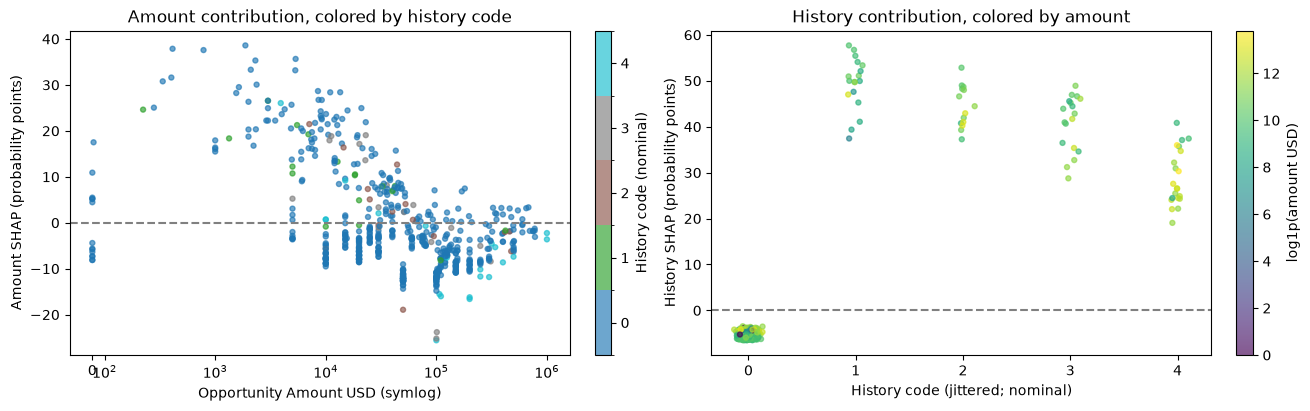

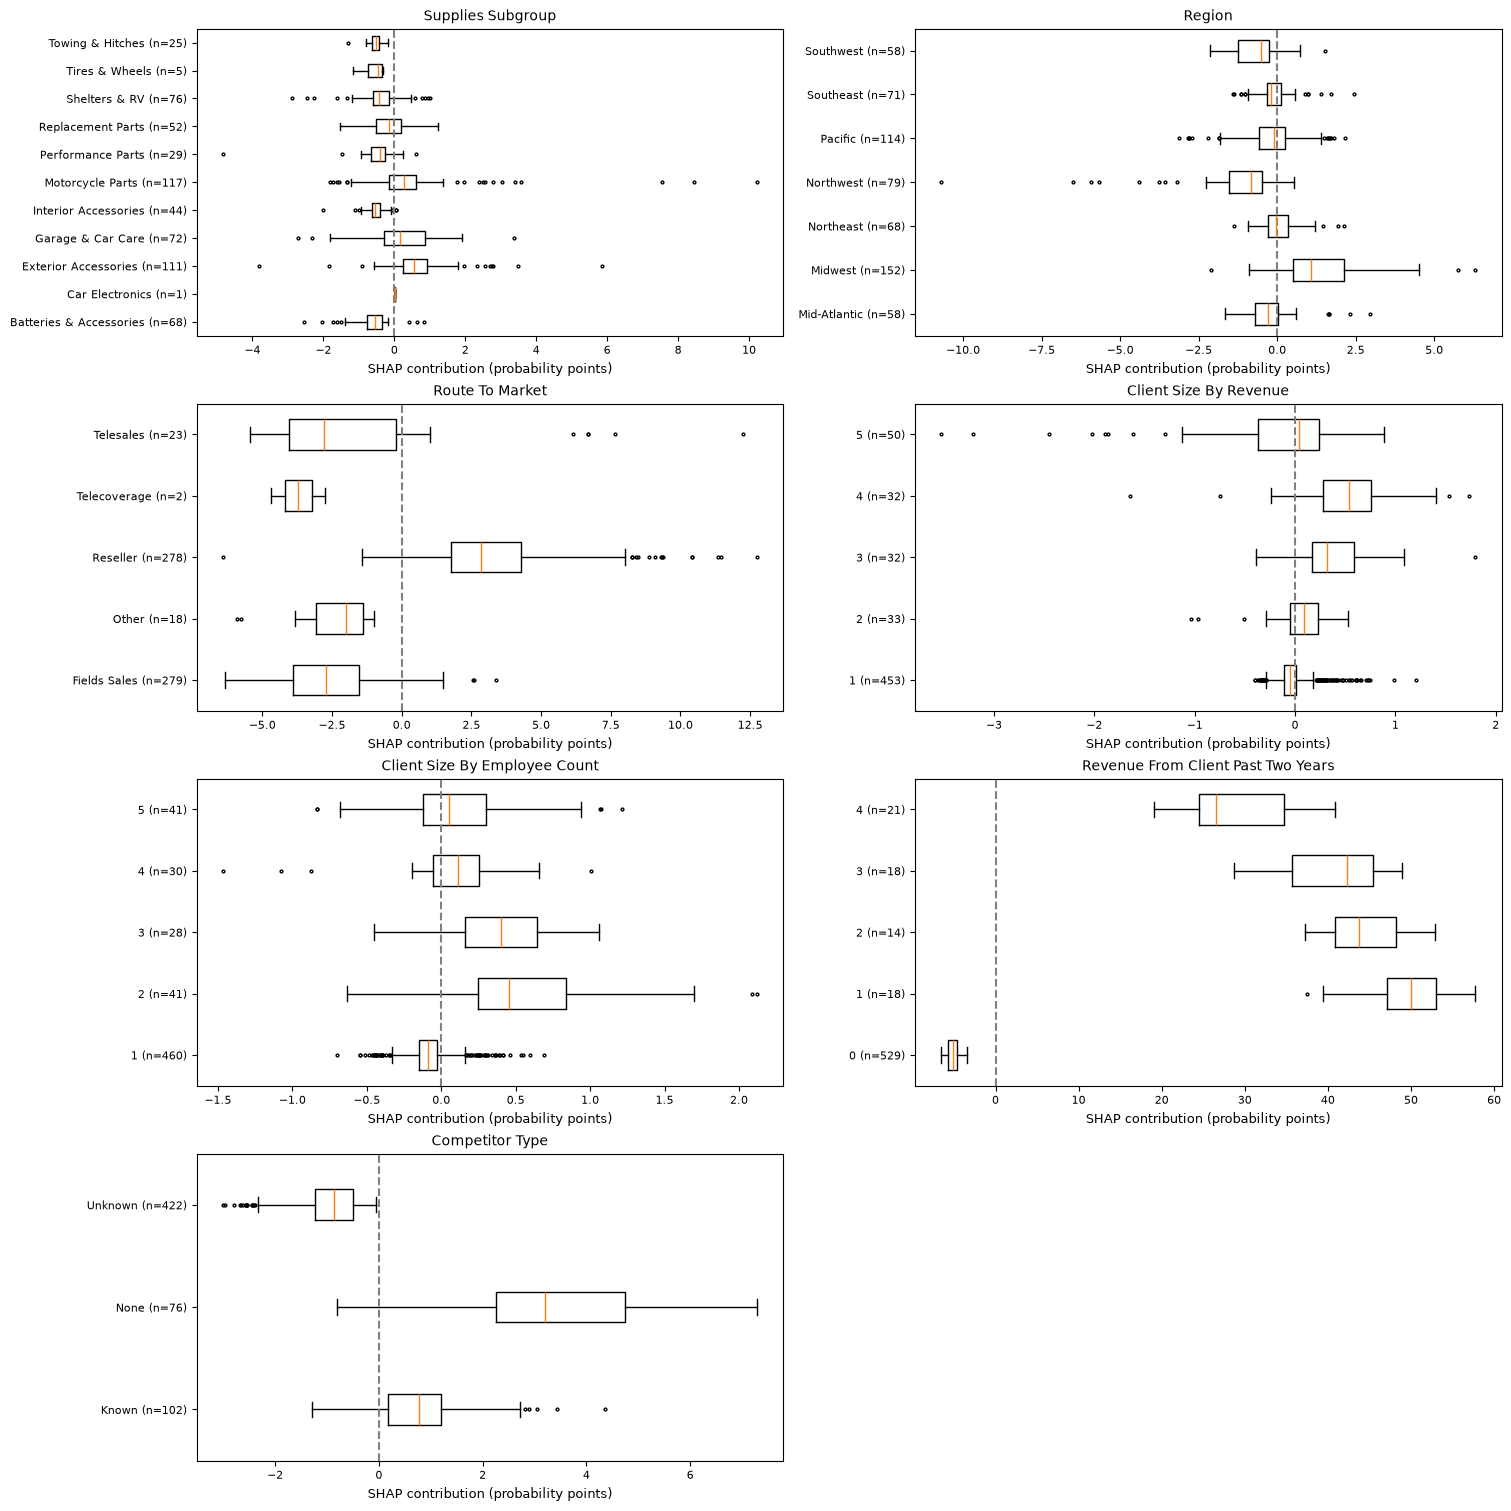

Each panel has its own horizontal scale; broad spreads suggest context dependence, not proven causal interactions.


In [9]:
from matplotlib.colors import BoundaryNorm

figure, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
history_colors = plt.get_cmap("tab10", 5)
history_norm = BoundaryNorm(np.arange(-0.5, 5.5), history_colors.N)
points = axes[0].scatter(audit_shap_sample[audit_amount], 100 * audit_shap_business[audit_amount],
                         c=audit_shap_sample[audit_history], cmap=history_colors, norm=history_norm,
                         s=13, alpha=0.65)
axes[0].set_xscale("symlog", linthresh=1000)
axes[0].axhline(0, color="grey", linestyle="--")
axes[0].set(xlabel="Opportunity Amount USD (symlog)", ylabel="Amount SHAP (probability points)",
            title="Amount contribution, colored by history code")
figure.colorbar(points, ax=axes[0], ticks=range(5), label="History code (nominal)")
jitter = np.random.default_rng(AUDIT_SEED).normal(0, 0.045, len(audit_shap_sample))
points = axes[1].scatter(audit_shap_sample[audit_history] + jitter, 100 * audit_shap_business[audit_history],
                         c=np.log1p(audit_shap_sample[audit_amount]), cmap="viridis", s=13, alpha=0.65)
axes[1].axhline(0, color="grey", linestyle="--")
axes[1].set(xlabel="History code (jittered; nominal)", ylabel="History SHAP (probability points)",
            title="History contribution, colored by amount", xticks=range(5))
figure.colorbar(points, ax=axes[1], label="log1p(amount USD)")
plt.show()

figure, axes = plt.subplots(4, 2, figsize=(15, 15), constrained_layout=True)
for axis, column in zip(axes.flat, audit_categorical):
    levels = sorted(audit_shap_sample[column].unique())
    grouped_values = [100 * audit_shap_business.loc[audit_shap_sample[column].eq(level), column]
                      for level in levels]
    labels = [f"{level} (n={len(values)})" for level, values in zip(levels, grouped_values)]
    axis.boxplot(grouped_values, orientation="horizontal", tick_labels=labels, showfliers=True,
                 flierprops={"markersize": 2})
    axis.axvline(0, color="grey", linestyle="--")
    axis.set_title(column, fontsize=10)
    axis.set_xlabel("SHAP contribution (probability points)", fontsize=9)
    axis.tick_params(labelsize=8)
axes.flat[-1].axis("off")
plt.show()
print("Each panel has its own horizontal scale; broad spreads suggest context dependence, not proven causal interactions.")

## Ablation

Keep the same training/validation rows, RF settings and log-amount representation. Positive ROC-AUC/AP changes and negative Brier changes are improvements over the full eight-field model. Removal can alter tree feature sampling, so small differences on one split are not definitive selection evidence. The three-field commercial model is a diagnostic simplification, not an approved replacement.

In [10]:
audit_removals = {
    "None (full)": [],
    "Opportunity amount": [audit_amount],
    "Prior-client revenue": [audit_history],
    "Product subgroup": ["Supplies Subgroup"],
    "Region": ["Region"],
    "Route to market": ["Route To Market"],
    "Both client-size fields": audit_profiles,
    "Competitor": [audit_competitor],
    "Product, region, size, competitor": ["Supplies Subgroup", "Region"] + audit_profiles + [audit_competitor],
}
audit_ablation_models, audit_ablation_probabilities, audit_ablation_rows = {}, {}, []
audit_reference_metrics = audit_quality(audit_validation["won"], audit_probability)
for removed, excluded in audit_removals.items():
    columns = [column for column in audit_candidates if column not in excluded]
    if removed == "None (full)":
        fitted = audit_full
    elif removed == "Competitor":
        fitted = audit_models["Seven-field"]
    else:
        fitted = audit_pipeline(columns).fit(audit_train[columns], audit_train["won"])
    probability = fitted.predict_proba(audit_validation[columns])[:, 1]
    measured = audit_quality(audit_validation["won"], probability)
    audit_ablation_models[removed] = fitted
    audit_ablation_probabilities[removed] = probability
    audit_ablation_rows.append({"Feature removed": removed, "Inputs": len(columns), **measured,
        **{f"delta_{metric}": measured[metric] - audit_reference_metrics[metric]
           for metric in ["ROC_AUC", "AP", "Brier"]}})
    print("Completed:", removed)
audit_ablation_table = pd.DataFrame(audit_ablation_rows).set_index("Feature removed")
display(audit_ablation_table.round(5))
print("All deltas are candidate minus full. No test predictions or parameter tuning.")

Completed: None (full)
Completed: Opportunity amount
Completed: Prior-client revenue
Completed: Product subgroup
Completed: Region
Completed: Route to market
Completed: Both client-size fields
Completed: Competitor
Completed: Product, region, size, competitor


,Inputs,ROC_AUC,AP,Brier,delta_ROC_AUC,delta_AP,delta_Brier
Feature removed,,,,,,,
None (full),8,0.81951,0.59844,0.12943,0.00000,0.00000,0.00000
Opportunity amount,7,0.73076,0.51333,0.14566,-0.08875,-0.08511,0.01623
Prior-client revenue,7,0.78042,0.48873,0.14412,-0.03910,-0.10971,0.01469
Product subgroup,7,0.81748,0.59597,0.12974,-0.00203,-0.00248,0.00031
Region,7,0.81820,0.59558,0.12971,-0.00131,-0.00286,0.00028
Route to market,7,0.81584,0.59333,0.12997,-0.00367,-0.00512,0.00054
Both client-size fields,6,0.81978,0.59902,0.12939,0.00027,0.00057,-0.00004
Competitor,7,0.82061,0.59776,0.12924,0.00110,-0.00068,-0.00018
"Product, region, size, competitor",3,0.81770,0.59038,0.13004,-0.00181,-0.00806,0.00061


All deltas are candidate minus full. No test predictions or parameter tuning.


In [11]:
audit_amount_models, audit_amount_rows = {}, []
for label, mode in [("Raw amount", "raw"), ("log1p amount", "log"), ("Fixed amount bands", "bands")]:
    fitted = audit_full if mode == "log" else audit_pipeline(audit_candidates, mode).fit(
        audit_train[audit_candidates], audit_train["won"])
    probability = fitted.predict_proba(audit_validation[audit_candidates])[:, 1]
    audit_amount_models[label] = fitted
    audit_amount_rows.append({"Representation": label, **audit_quality(audit_validation["won"], probability)})

audit_amount_cap = float(audit_train[audit_amount].quantile(0.99))
audit_capped_train = audit_train.assign(**{audit_amount: audit_train[audit_amount].clip(upper=audit_amount_cap)})
audit_capped_validation = audit_validation.assign(**{audit_amount: audit_validation[audit_amount].clip(upper=audit_amount_cap)})
audit_capped_model = audit_pipeline(audit_candidates).fit(audit_capped_train[audit_candidates], audit_capped_train["won"])
audit_capped_probability = audit_capped_model.predict_proba(audit_capped_validation[audit_candidates])[:, 1]
audit_amount_rows.append({"Representation": "log1p, capped at training p99",
                         **audit_quality(audit_validation["won"], audit_capped_probability)})

audit_logistic = audit_pipeline(audit_candidates, estimator=LogisticRegression(
    C=1.0, max_iter=1500, random_state=AUDIT_SEED)).fit(audit_train[audit_candidates], audit_train["won"])
audit_logistic_probability = audit_logistic.predict_proba(audit_validation[audit_candidates])[:, 1]
audit_amount_rows.append({"Representation": "Logistic Regression / log1p",
                         **audit_quality(audit_validation["won"], audit_logistic_probability)})
audit_amount_comparison = pd.DataFrame(audit_amount_rows).set_index("Representation")
for metric in ["ROC_AUC", "AP", "Brier"]:
    audit_amount_comparison[f"delta_{metric}"] = audit_amount_comparison[metric] - audit_reference_metrics[metric]
display(audit_amount_comparison.round(5))
print("Training-only p99 cap (USD):", audit_amount_cap)
print("Validation rows above cap:", int(audit_validation[audit_amount].gt(audit_amount_cap).sum()))
print("Exactly one amount representation per model. The cap is a sensitivity test, not a manual prediction correction.")

,ROC_AUC,AP,Brier,delta_ROC_AUC,delta_AP,delta_Brier
Representation,,,,,,
Raw amount,0.81948,0.59841,0.12943,-0.00003,-0.00004,0.00001
log1p amount,0.81951,0.59844,0.12943,0.00000,0.00000,0.00000
Fixed amount bands,0.77314,0.54617,0.13939,-0.04637,-0.05228,0.00996
"log1p, capped at training p99",0.81946,0.59833,0.12942,-0.00005,-0.00011,-0.00001
Logistic Regression / log1p,0.73024,0.49780,0.14718,-0.08927,-0.10064,0.01775


Training-only p99 cap (USD): 697566.0
Validation rows above cap: 180
Exactly one amount representation per model. The cap is a sensitivity test, not a manual prediction correction.


## Segment Evaluation

Fit sigmoid calibration only on the reserved **calibration** partition, then inspect raw and calibrated validation probabilities. Do not use SHAP to modify probabilities. Segment metrics describe the current validation population, not verified customer types or evidence that separate models would improve results. Overall calibration can hide segment errors.

,Model,Variant,ROC_AUC,AP,Brier,Mean_probability,Observed_win_rate
0,Seven-field,raw,0.82061,0.59776,0.12924,0.22421,0.22525
1,Seven-field,sigmoid,0.82061,0.59776,0.12937,0.22767,0.22525
2,Full eight-field,raw,0.81951,0.59844,0.12943,0.22456,0.22525
3,Full eight-field,sigmoid,0.81951,0.59844,0.12954,0.22841,0.22525


Raw fixed-width reliability bins:


,Opportunities,Observed_win_rate,Average_probability
bin,,,
"(-0.001, 0.1]",5094,0.0495,0.0541
"(0.1, 0.2]",4383,0.1303,0.1433
"(0.2, 0.3]",2026,0.2488,0.2416
"(0.3, 0.4]",1345,0.3814,0.3516
"(0.4, 0.5]",1091,0.5032,0.4453
"(0.5, 0.6]",348,0.5287,0.5352
"(0.6, 0.7]",335,0.6388,0.6539
"(0.7, 0.8]",484,0.7231,0.7486
"(0.8, 0.9]",354,0.8249,0.8410


Sigmoid fixed-width reliability bins:


,Opportunities,Observed_win_rate,Average_probability
bin,,,
"(-0.001, 0.1]",5791,0.0535,0.0500
"(0.1, 0.2]",3819,0.1388,0.1432
"(0.2, 0.3]",1748,0.2529,0.2419
"(0.3, 0.4]",1142,0.3713,0.3503
"(0.4, 0.5]",1088,0.4513,0.4470
"(0.5, 0.6]",605,0.5372,0.5407
"(0.6, 0.7]",212,0.5708,0.6533
"(0.7, 0.8]",428,0.6636,0.7550
"(0.8, 0.9]",504,0.7837,0.8485


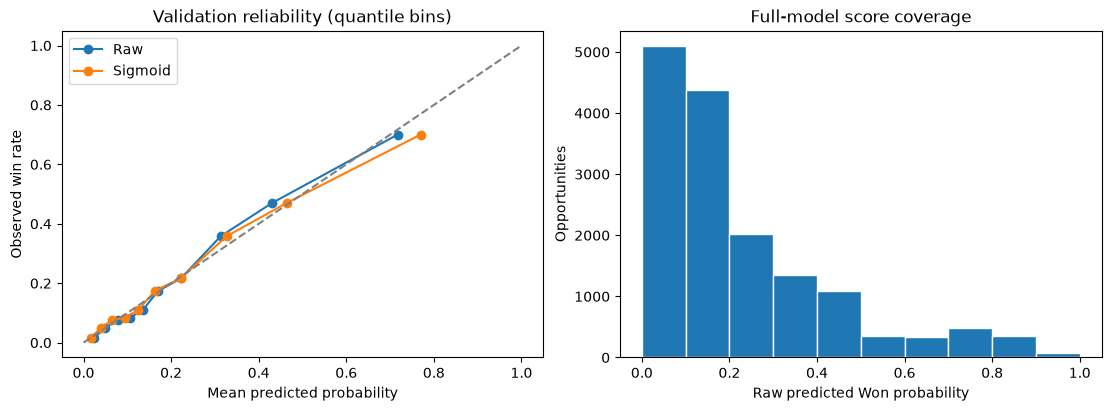

In [12]:
from sklearn.calibration import calibration_curve

def audit_log_odds(probability):
    bounded = np.clip(np.asarray(probability), 1e-6, 1 - 1e-6)
    return np.log(bounded / (1 - bounded)).reshape(-1, 1)

audit_calibrators, audit_calibrated, audit_calibration_rows = {}, {}, []
for name in ["Seven-field", "Full eight-field"]:
    fitted = audit_models[name]
    columns = list(fitted.feature_names_in_)
    calibration_probability = fitted.predict_proba(audit_calibration[columns])[:, 1]
    raw_probability = fitted.predict_proba(audit_validation[columns])[:, 1]
    calibrator = LogisticRegression(C=1e6, solver="lbfgs", max_iter=1000)
    calibrator.fit(audit_log_odds(calibration_probability), audit_calibration["won"])
    calibrated_probability = calibrator.predict_proba(audit_log_odds(raw_probability))[:, 1]
    audit_calibrators[name], audit_calibrated[name] = calibrator, calibrated_probability
    for variant, probability in [("raw", raw_probability), ("sigmoid", calibrated_probability)]:
        audit_calibration_rows.append({"Model": name, "Variant": variant,
            **audit_quality(audit_validation["won"], probability),
            "Mean_probability": probability.mean(), "Observed_win_rate": audit_validation["won"].mean()})
display(pd.DataFrame(audit_calibration_rows).round(5))

audit_observed["calibrated_probability"] = audit_calibrated["Full eight-field"]
figure, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
audit_reliability_tables = {}
for name, probability in [("Raw", audit_probability), ("Sigmoid", audit_calibrated["Full eight-field"])]:
    observed, predicted = calibration_curve(audit_validation["won"], probability, n_bins=10, strategy="quantile")
    axes[0].plot(predicted, observed, "o-", label=name)
    bins = pd.cut(probability, np.linspace(0, 1, 11), include_lowest=True)
    table = pd.DataFrame({"bin": bins, "actual": audit_validation["won"].to_numpy(), "probability": probability})
    table = table.groupby("bin", observed=False).agg(
        Opportunities=("actual", "size"), Observed_win_rate=("actual", "mean"), Average_probability=("probability", "mean"))
    audit_reliability_tables[name] = table
    print(name, "fixed-width reliability bins:")
    display(table.round(4))
axes[0].plot([0, 1], [0, 1], "--", color="grey")
axes[0].set(xlabel="Mean predicted probability", ylabel="Observed win rate", title="Validation reliability (quantile bins)")
axes[0].legend()
axes[1].hist(audit_probability, bins=np.linspace(0, 1, 11), edgecolor="white")
axes[1].set(xlabel="Raw predicted Won probability", ylabel="Opportunities", title="Full-model score coverage")
plt.show()

In [13]:
audit_observed["size_segment"] = np.select(
    [audit_observed[audit_amount].eq(0), audit_observed[audit_amount].lt(25000), audit_observed[audit_amount].lt(100000)],
    ["Zero", "Small: 1-24,999", "Medium: 25,000-99,999"], default="Large: >=100,000",
 )
audit_segment_rows = []
for group_name, column in [("Amount", "size_segment"), ("History code", audit_history)]:
    for category, segment in audit_observed.groupby(column, observed=True):
        observed_rate = segment["won"].mean()
        measured = audit_quality(segment["won"], segment["probability"])
        enough_classes = min(segment["won"].sum(), segment["won"].eq(0).sum()) >= 10
        audit_segment_rows.append({
            "Grouping": group_name, "Segment": str(category), "Opportunities": len(segment),
            "Wins": int(segment["won"].sum()), "Observed_win_rate": observed_rate,
            "Average_probability": segment["probability"].mean(),
            "ROC_AUC": measured["ROC_AUC"] if enough_classes else np.nan,
            "AP": measured["AP"], "Brier": measured["Brier"],
            "Calibration_gap": segment["probability"].mean() - observed_rate,
            "Sigmoid_Brier": brier_score_loss(segment["won"], segment["calibrated_probability"]),
            "Sigmoid_gap": segment["calibrated_probability"].mean() - observed_rate,
        })
audit_segments = pd.DataFrame(audit_segment_rows).set_index(["Grouping", "Segment"])
display(audit_segments.round(4))
print("Calibration gap = mean prediction - observed win rate; positive means overprediction.")
print("AUC suppressed below 10 positives or negatives. AP/Brier vary with segment prevalence.")

for frame in [audit_train, audit_calibration, audit_validation]:
    assert set(frame["Opportunity Number"]).isdisjoint(audit_reserved["Opportunity Number"])
assert not set(audit_candidates) & {"Opportunity Number", "Opportunity Result", "won", "Deal Size Category", "Supplies Group"}
assert np.isfinite(audit_probability).all() and ((audit_probability >= 0) & (audit_probability <= 1)).all()
assert np.allclose(audit_probability, audit_full.predict_proba(audit_validation[audit_candidates])[:, 1])
print("Audit checks passed: unchanged raw probabilities; excluded fields absent; test IDs isolated.")

Opportunities  Wins  Observed_win_rate  \
Grouping     Segment                                                         
Amount       Large: >=100,000                5062   739             0.1460   
             Medium: 25,000-99,999           5159  1040             0.2016   
             Small: 1-24,999                 4929  1661             0.3370   
             Zero                             388    60             0.1546   
History code 0                              13752  2392             0.1739   
             1                                344   278             0.8081   
             2                                427   315             0.7377   
             3                                390   217             0.5564   
             4                                625   298             0.4768   

                                    Average_probability  ROC_AUC      AP  \
Grouping     Segment                                                       
Amount       Large: >=100,000                    0.1375   0.8229  0.4884   
             Medium: 25,000-99,999               0.2074   0.8059  0.5741   
             Small: 1-24,999                     0.3358   0.7878  0.6584   
             Zero                                0.1747   0.7499  0.3529   
History code 0                                   0.1721   0.7798  0.4253   
             1                                   0.8159   0.6891  0.8838   
             2                                   0.6994   0.6786  0.8399   
             3                                   0.6200   0.6841  0.7002   
             4                                   0.4828   0.7282  0.6586   

                                     Brier  Calibration_gap  Sigmoid_Brier  \
Grouping     Segment                                                         
Amount       Large: >=100,000       0.0975          -0.0085         0.0974   
             Medium: 25,000-99,999  0.1216           0.0059         0.1213   
             Small: 1-24,999        0.1713          -0.0012         0.1719   
             Zero                   0.1185           0.0201         0.1200   
History code 0                      0.1212          -0.0019         0.1210   
             1                      0.1377           0.0078         0.1400   
             2                      0.1774          -0.0383         0.1762   
             3                      0.2248           0.0636         0.2333   
             4                      0.2134           0.0060         0.2143   

                                    Sigmoid_gap  
Grouping     Segment                             
Amount       Large: >=100,000           -0.0112  
             Medium: 25,000-99,999       0.0058  
             Small: 1-24,999             0.0138  
             Zero                        0.0188  
History code 0                          -0.0031  
             1                           0.0526  
             2                           0.0127  
             3                           0.1093  
             4                           0.0414

Calibration gap = mean prediction - observed win rate; positive means overprediction.
AUC suppressed below 10 positives or negatives. AP/Brier vary with segment prevalence.
Audit checks passed: unchanged raw probabilities; excluded fields absent; test IDs isolated.


## Dataset Behaviour Findings

**Development audit only.** The original evaluation is preserved; new work uses training/calibration/validation, not test predictions. Full eight-field RF: AUC **0.81951**, AP **0.59844**, Brier **0.12943**. Seven-field reference: AUC **0.82061**, Brier **0.12924**.

### Predictive Structure

| Feature | Observed/model direction | Conclusion |
|---|---|---|
| Opportunity Amount USD | Low nonzero amounts usually raise predictions; middle/high amounts generally lower them, with a rebound at the top. Zero behaves separately. | Central: removal drops AUC **0.08875**. Not a rule that expensive deals win. |
| Revenue From Client Past Two Years | Code 0 lowers predictions; codes 1-4 raise them. Validation win rates are **17.39%, 80.81%, 73.77%, 55.64%, 47.68%**. | Largest mean absolute SHAP; removal drops AUC **0.03910**, AP **0.10971**. Additive signal, but code meanings/timing remain unverified. |
| Route To Market | Reseller generally raises predictions; Fields Sales/Other lower them. Among USD 100,000-249,999 deals, Reseller wins about 27% versus 9% for Fields Sales. | Third in SHAP/permutation importance; removal drops AUC **0.00367**. Contextual association, not a channel recommendation. |
| Region | Midwest tends positive; Northwest/Southwest negative, with variation across records. | Small contribution: removal drops AUC **0.00131**. No geographic-transfer claim. |
| Supplies Subgroup / Group | Marginal win rates differ, but conditional subgroup effects are small/mixed. Group is determined by subgroup. | Subgroup removal drops AUC **0.00203**. Product is not the main discriminator; rare groups have weak support. |
| Client Size By Revenue | Small, non-monotonic code effects. Every history code spans all five size codes. | History is not merely duplicated client size. Weak conditional size contribution. |
| Client Size By Employee Count | Contributions cluster near zero; conditional effects can differ from marginal rates. | Removing both size fields changes AUC **+0.00027**, Brier **-0.00004**: negligible necessity here. |
| Competitor Type | None tends positive, Unknown negative; Known can be positive conditionally despite a lower marginal win rate. | Some reliance, but removal improves AUC **0.00110** and Brier **0.00018**. Not necessary in the candidate set. |

SHAP/native/permutation scales differ and measure reliance, not causality or necessity. Ablation tests retrained performance; small differences on one split need replication.

### Amount And Shortcut Risk

- Observed wins are **44.22%** at USD 1-9,999, fall to **12.73%** at USD 100,000-249,999, then rise to **17.35% / 22.98%** in the highest bands. Zero has **15.46%** wins. No monotonic constraint is justified.
- The **432** predictions at or above 80% have median amount **USD 12,084**; about **99.3%** have nonzero history. None at USD 250,000 or above receives an 80% prediction. High value is not automatically producing high probability.
- Raw/log RF AUC is almost identical (**0.81948 / 0.81951**). Coarse bands fall to **0.77314**; a training-p99 cap leaves AUC at **0.81946**. Extreme values do not explain the overall gain, but finer amount detail matters.
- History and route change the amount relationship. Heatmaps show observed/predicted differences and mask sparse cells. These are associations, not proven causal interactions.
- **Unhealthy shortcut: unresolved.** Opaque history codes and exact-amount patterns could reflect business structure, sampling/export rules or later updates. Agreement with this extract does not prove valid prediction-time availability.

### Calibration And Stability

Small/medium/large segments retain AUC **0.7878 / 0.8059 / 0.8229** and mean prediction-minus-outcome gaps **-0.12 / +0.59 / -0.85 percentage points**. Zero amounts are overpredicted by **2.01 points**. Discrimination is not only a difference between value bands.

History code 0 retains within-group AUC **0.7798**; codes 1-4 range **0.6786-0.7282**. Code 3 is overpredicted by **6.36 points**, with larger gaps in some small amount/history cells. Telecoverage has only 5 wins in 120 validation records and is also overpredicted.

Sigmoid calibration worsens overall Brier for both richer models and increases the code-3 gap to **10.93 points**. Keep raw probabilities as the current reference, not manually SHAP-adjusted scores. One random split, sparse groups and no customer/date keys limit stability claims.

### Project Implications

- **Domain:** The dataset contains automotive-supply categories, but the predictive problem is not primarily product-specific. Prefer the provisional framing **B2B Sales Opportunity Management and Predictive Decision Support System**. B2B identity and cross-industry transfer remain unverified; evaluated performance is an IBM-source case study.
- **Candidate features:** next compare **Opportunity Amount USD, Revenue From Client Past Two Years, Route To Market** with the seven-field reference. This lean model reaches AUC **0.81770**, AP **0.59038**, Brier **0.13004**. Product/region are optional pending replication; size/competitor show little necessity. Exclude target, IDs, progression/duration and redundant fields.
- **Generalizability:** amount, history and route are reusable business concepts, not validated transferable encodings. Size is reusable but weak here; region and product values are source-specific.
- **Model count:** keep one model. Value/history groups are useful diagnostics, but no separate-model advantage is established. Code 0 is not a verified new-customer state; no snapshots define early/qualified populations.
- **Commercial priority:** the target stays eventual Won probability. A future rule may use $pV$ for commercial attention; never increase probability merely because the amount is high. No prioritization policy or sales uplift was validated here.
- **Next experiment:** prespecified development-only repeats of lean versus seven-field models, finer amount/history checks, and group calibration. Test sensitivity to rounding or training-defined quantile bands. Obtain source definitions and prediction-time evidence before final dataset selection; do not tune against the inspected test.

No project-direction Markdown files were changed during this audit. Earlier notebook conclusions remain historical evidence; this section records the new findings.